# **Olist ecommerce data cleaning**
---
https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

### How this notebook is organised

- **Understanding and exploring all csv files** — the schema, and loading the nine tables.
- **Checking shape, dtypes and missing values** — what each table holds before anything is touched.
- **Converting dtypes** — identifiers to text, timestamps to datetime.
- **Checking missing values** — where they sit, whether they cluster, and what is done about each group.
- **Checking for duplicates** — the declared grain of each table, tested.
- **Referential integrity** — whether every key points at a row that exists, and whether any row is never pointed at.
- **Translation coverage** — whether the category lookup covers every category the products hold.
- **Geolocation coverage** — whether every zip prefix in use has coordinates.
- **Cross-table consistency** — whether two tables describing the same thing agree: order value against payments (A), prefixes against coordinates (B), timestamps across tables (C), status against the child tables (D).
- **Value ranges and typos** — whether a single value, on its own, can exist: bounds, closed sets, date windows, the coordinate box, and free text.
- **Monotonicity** — whether the timestamps of an order follow the order of the events they record.
- **Geolocation aggregation** — reducing geolocation to one point per zip prefix, and deciding which point that is.
- **Export and summary** — writing the cleaned tables out and stating what was found, corrected and left alone.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import missingno as msno
%matplotlib inline 
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

### **Understanding and exploring all csv files**

#### **data schema :**

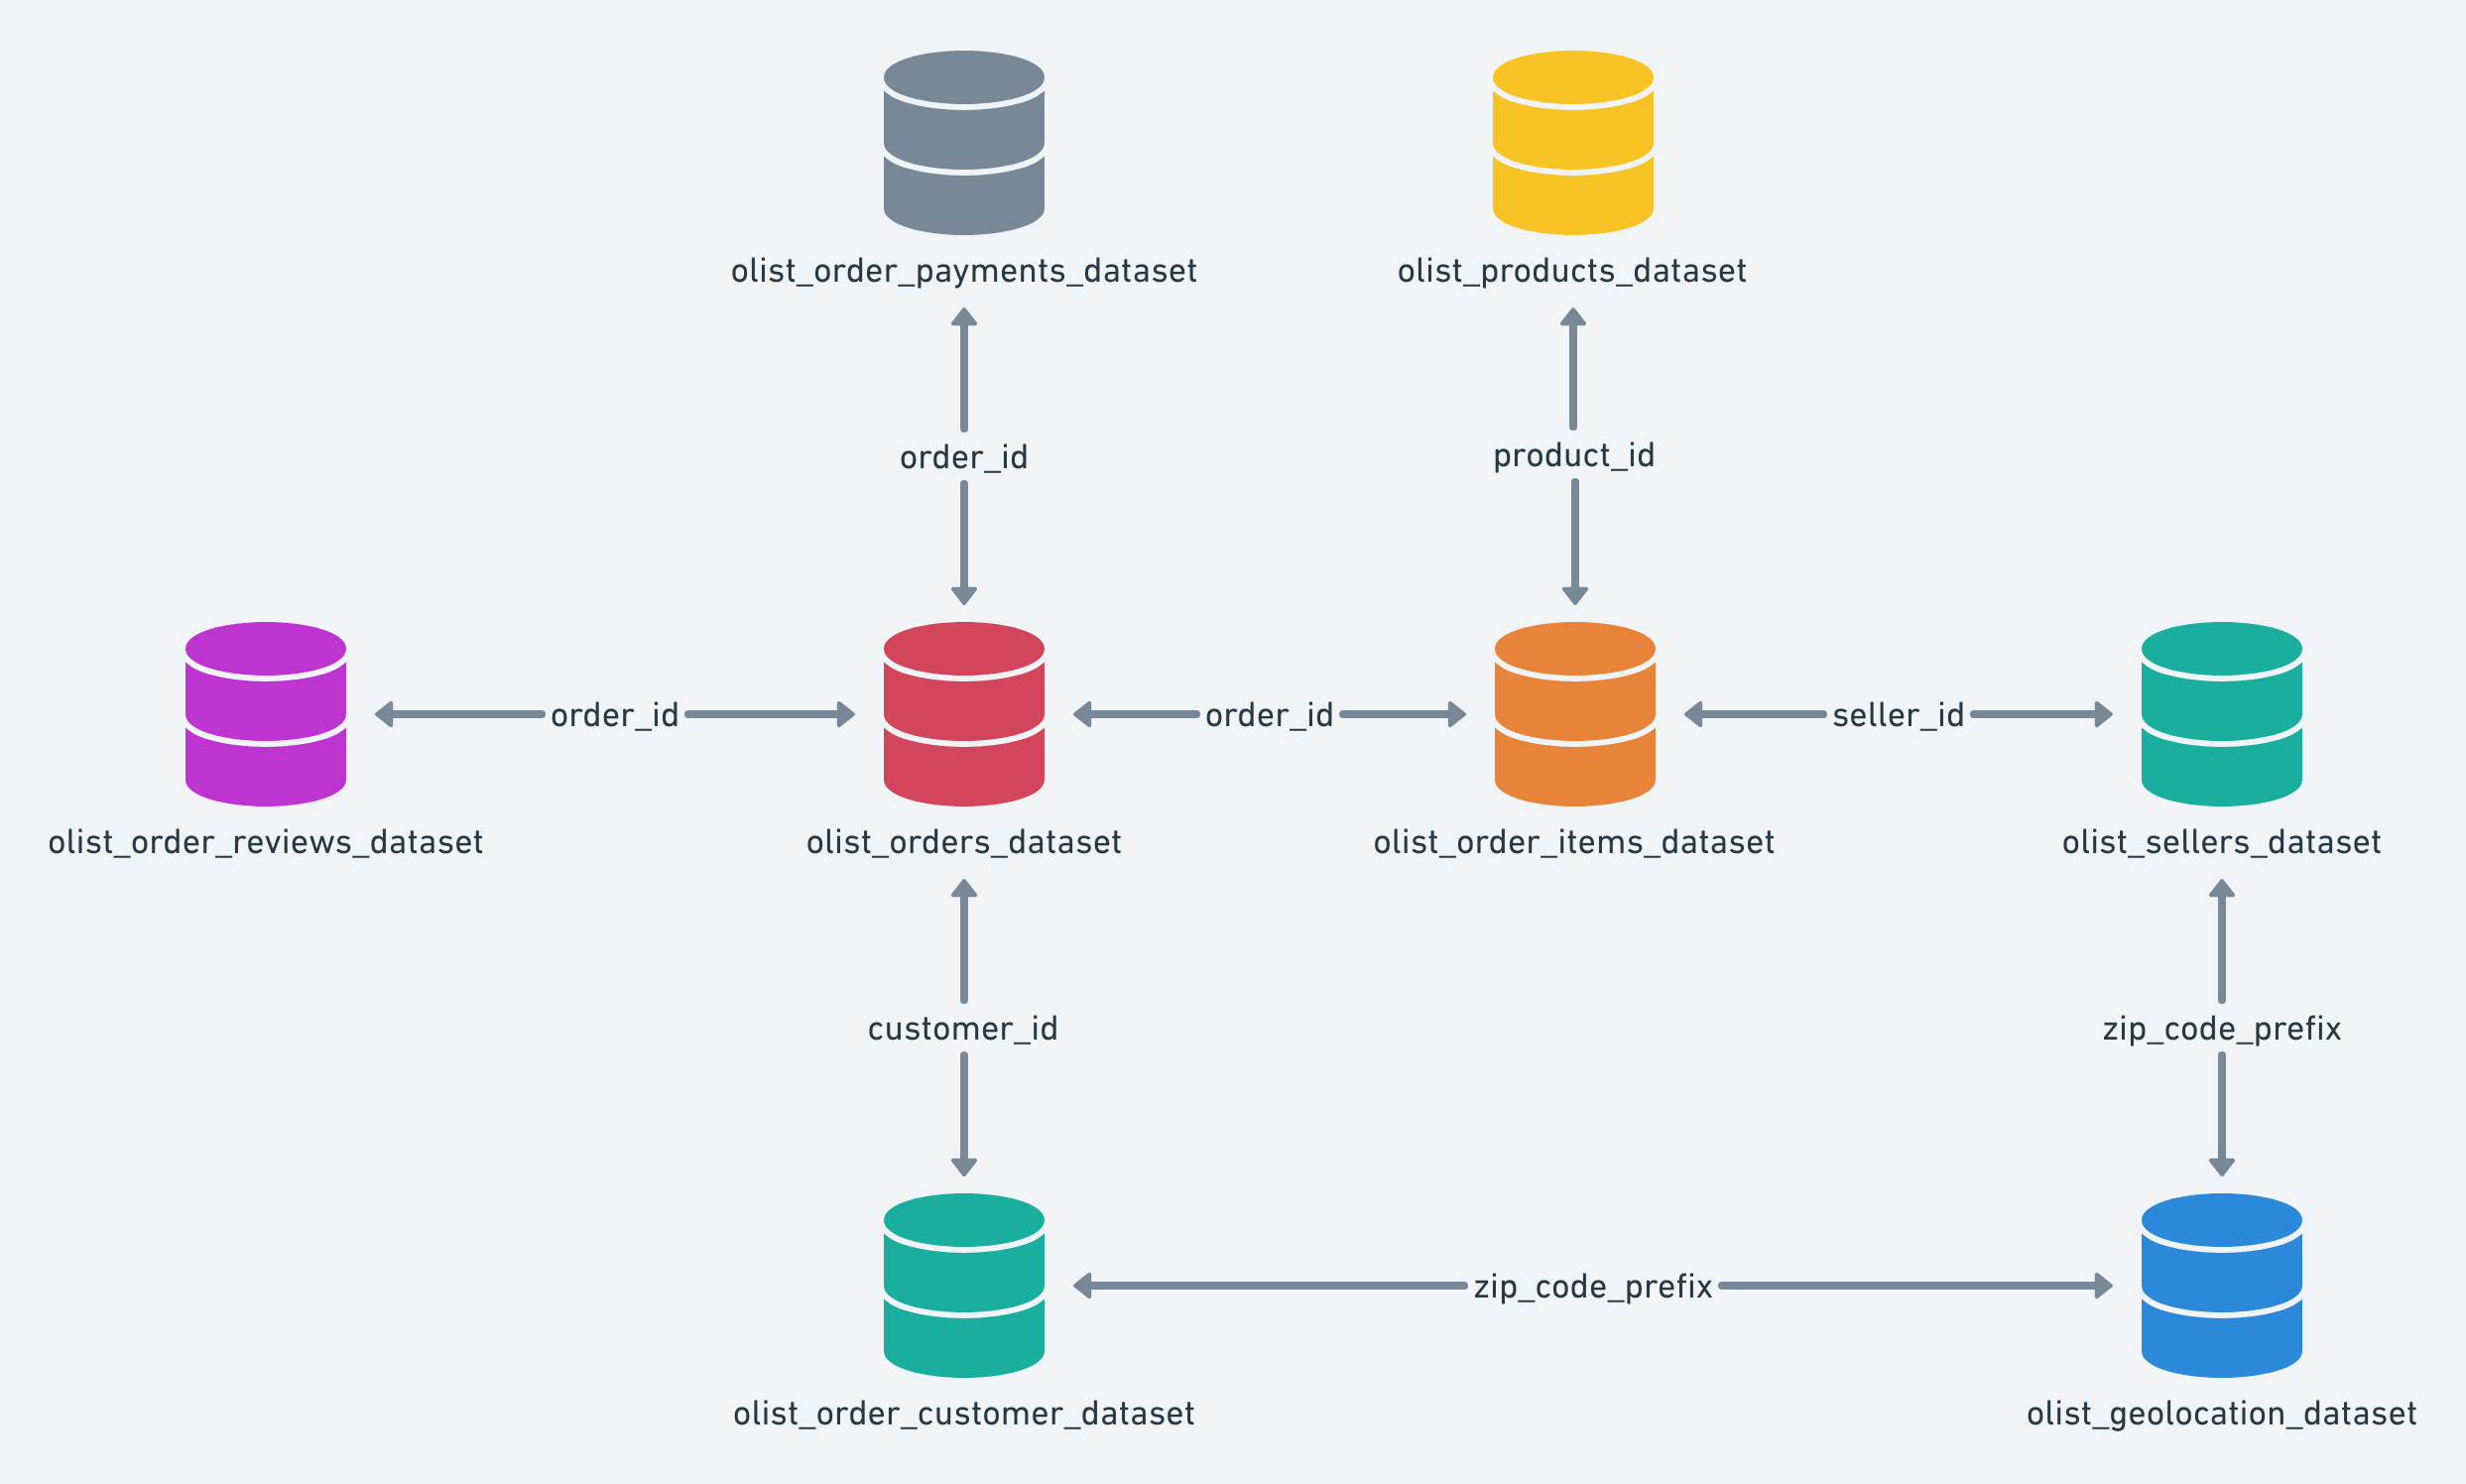

##### Loading all datasets

In [2]:
customers = pd.read_csv("data/olist_customers_dataset.csv")
geolocation = pd.read_csv("data/olist_geolocation_dataset.csv")
order_items = pd.read_csv("data/olist_order_items_dataset.csv")
order_payments = pd.read_csv("data/olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("data/olist_order_reviews_dataset.csv")
orders = pd.read_csv("data/olist_orders_dataset.csv")
products = pd.read_csv("data/olist_products_dataset.csv")
sellers = pd.read_csv("data/olist_sellers_dataset.csv")
prod_categ_name_transl = pd.read_csv("data/product_category_name_translation.csv")

---

## **Checking their shape, dtypes and missing values**

In [3]:
dataframes = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "prod_categ_name_transl": prod_categ_name_transl
}

In [4]:
for name, dataframe in dataframes.items():
    print(f"{name} shape is : {dataframe.shape}")

customers shape is : (99441, 5)
geolocation shape is : (1000163, 5)
order_items shape is : (112650, 7)
order_payments shape is : (103886, 5)
order_reviews shape is : (99224, 7)
orders shape is : (99441, 8)
products shape is : (32951, 9)
sellers shape is : (3095, 4)
prod_categ_name_transl shape is : (71, 2)


orders and customers have the same amount of rows, so there is high possibility that their relation is 1:1.

order_items has more rows than orders, so an order can have multiple items. order_payments likewise, showing a possible 1:N relation between orders and order_payments.

geolocation has ≈ 1mill rows because there are multiple lat/lng points per zip code prefix. This will require aggregation before merging with customers or sellers.

reviews are fewer than orders, so joining them needs care.

In [5]:
for name, dataframe in dataframes.items():
    print(f"\n{name}")
    dataframe.info() 


customers
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 11.0 MB

geolocation
<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    


#### Results

At this stage I have only checked missing values and dtypes.

**customers** -> No missing values. Dtypes OK.

**geolocation** -> No missing values. Dtypes OK. Still needs aggregation to one point per zip code prefix before it can be joined, as noted above.

**order_items** -> No missing values. `shipping_limit_date` is str, needs conversion to datetime.

**order_payments** -> No missing values. Dtypes OK.

**order_reviews** -> Missing: `review_comment_title`, `review_comment_message`. `review_creation_date`, `review_answer_timestamp` need conversion to datetime.

**orders** -> Missing: `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`. All 5 timestamp features need conversion to datetime.

**products** -> Missing: `product_category_name`, `product_name_lenght`, `product_description_lenght`, `product_photos_qty` (610 each, also most likely the same rows). `product_weight_g`, `product_length_cm`, `product_height_cm`, `product_width_cm` (2 each, also most likely the same rows). Float dtypes cause of NaN.

**sellers** -> No missing values. Dtypes OK.

**prod_categ_name_transl** -> No missing values. Dtypes OK.

Duplicates, value ranges and referential integrity are not assessed yet, so none of these entries says a table is clean overall.

---

## **Converting dtypes**

The raw frames loaded from the CSVs stay untouched as a record of the original state. Every modification goes to a `_clean` copy instead, and `dataframes_clean` mirrors `dataframes` so both states stay available for comparison.

In [6]:
customers_clean = customers.copy()
geolocation_clean = geolocation.copy()
order_items_clean = order_items.copy()
order_payments_clean = order_payments.copy()
order_reviews_clean = order_reviews.copy()
orders_clean = orders.copy()
products_clean = products.copy()
sellers_clean = sellers.copy()
prod_categ_name_transl_clean = prod_categ_name_transl.copy()

dataframes_clean = {
    "customers": customers_clean,
    "geolocation": geolocation_clean,
    "order_items": order_items_clean,
    "order_payments": order_payments_clean,
    "order_reviews": order_reviews_clean,
    "orders": orders_clean,
    "products": products_clean,
    "sellers": sellers_clean,
    "prod_categ_name_transl": prod_categ_name_transl_clean
}

In [7]:
order_items_clean["shipping_limit_date"] = pd.to_datetime(order_items_clean["shipping_limit_date"])

order_reviews_clean["review_creation_date"] = pd.to_datetime(order_reviews_clean["review_creation_date"])
order_reviews_clean["review_answer_timestamp"] = pd.to_datetime(order_reviews_clean["review_answer_timestamp"])

orders_date_columns = ["order_purchase_timestamp", "order_approved_at",
                         "order_delivered_carrier_date", "order_delivered_customer_date",
                         "order_estimated_delivery_date"]

for col in orders_date_columns:
    orders_clean[col] = pd.to_datetime(orders_clean[col])

Checking if the conversions worked

In [8]:
order_items_clean.info()
order_reviews_clean.info()
orders_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  str           
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  str           
 3   seller_id            112650 non-null  str           
 4   shipping_limit_date  112650 non-null  datetime64[us]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 16.3 MB
<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  str           
 1   order_id        

All columns got converted correctly 

---

## **Checking missing values** 

Starting from `products`: 610 rows have missing values in 4 columns. First, whether those missing values fall on the same rows across all 4.

In [9]:
products_metadata_cols = ["product_category_name", "product_name_lenght",
                           "product_description_lenght", "product_photos_qty"]

products_clean[products_metadata_cols].isna().sum(axis = 1).value_counts()

0    32341
4      610
Name: count, dtype: int64

The 4 columns share the same missing rows: 610 products are missing all four fields.

##### Downstream impact of the 610 products with missing metadata

Before deciding between dropping and imputing, I need to know what these products
represent in the transactional data:

- how many `order_items` rows reference the 610 products
- how many of the 610 appear in `order_items` at all
- how many distinct orders those rows belong to
- what share of total product sales value (`price`) they account for

Checking `product_id` uniqueness in `products`: if the grain is one row per product, the 610 rows with missing metadata are 610 distinct products.

In [10]:
products_clean["product_id"].is_unique

True

All 32951 products are unique, so the table's grain is one row per product and the 610 products with missing values are distinct.

##### Understanding the grain of `order_items`

What a single row represents determines whether summing `price` gives a valid total product sales value figure.

Inspecting a multi-item order shows that the same `product_id` can repeat within one `order_id`, with only `order_item_id` differing. This suggests the table's key is the pair (`order_id`, `order_item_id`) rather than `product_id` alone, and raises the question of whether `price` applies to the row or to the whole order.

In [11]:
order_items_clean.duplicated(subset = ["order_id", "order_item_id"]).sum()

np.int64(0)

The pair (`order_id`, `order_item_id`) uniquely identifies each row in `order_items`.

Orders containing two or more different products show different `price` values on each row, so `price` is row-level and can be summed to measure product sales value. If `price` referred to the order total it would be identical on every row of an order, so a single counter-example is enough to rule that out.

**`023669233121f0fb7899e5be2b22885f`**

| order_item_id | product_id | price |
|---|---|---|
| 1 | 6b6b162b… | 109.99 |
| 2 | 4dba4de4… | 38.90 |
| 3 | 784c94d1… | 109.90 |

**`005d9a5423d47281ac463a968b3936fb`**

| order_item_id | product_id | price |
|---|---|---|
| 1 | fb7a100e… | 49.99 |
| 2 | 4c3ae5db… | 24.99 |
| 3 | 4c3ae5db… | 24.99 |

The second example also shows there is no quantity column: the same `product_id` occupies two rows of the same order, with only `order_item_id` differing, so buying a product more than once is recorded by repeating the row rather than by a number in a quantity field. A row is therefore one order-item occurrence, not an aggregated (`order_id`, `product_id`) line — counting rows is what measures quantity, and summing the row-level `price` values is consistent with that grain, since each unit contributes its own row and its own price.

Isolating the `product_id` values of the 610 products with missing metadata, to trace them in `order_items`.

In [12]:
products_missing_vals = products_clean["product_category_name"].isna()
missing_metadata_product_ids = products_clean[products_missing_vals]["product_id"]

missing_metadata_product_ids

105      a41e356c76fab66334f36de622ecbd3a
128      d8dee61c2034d6d075997acef1870e9b
145      56139431d72cd51f19eb9f7dae4d1617
154      46b48281eb6d663ced748f324108c733
197      5fb61f482620cb672f5e586bb132eae9
                       ...               
32515    b0a0c5dd78e644373b199380612c350a
32589    10dbe0fbaa2c505123c17fdc34a63c56
32616    bd2ada37b58ae94cc838b9c0569fecd8
32772    fa51e914046aab32764c41356b9d4ea4
32852    c4ceee876c82b8328e9c293fa0e1989b
Name: product_id, Length: 610, dtype: str

A boolean mask over `order_items` flagging every row that references one of these products. All four measurements below are derived from this single mask.

In [13]:
mask_missing_metadata = order_items_clean["product_id"].isin(missing_metadata_product_ids)

##### 1. `order_items` rows referencing the 610 products

In [14]:
rows_affected = mask_missing_metadata.sum() 
pct_of_all_order_items = rows_affected / len(mask_missing_metadata) * 100

print(f"rows_affected = {rows_affected}, pct_of_all_order_items = {pct_of_all_order_items:.2f}%")

rows_affected = 1603, pct_of_all_order_items = 1.42%


Rows referencing these products: 1603 of 112650 -> 1.42%

##### 2. How many of the 610 appear in `order_items` at all

In [15]:
products_found = order_items_clean["product_id"][mask_missing_metadata].nunique()
products_found_pct = products_found / len(missing_metadata_product_ids) *100

print(f"products_found = {products_found}, products_found_pct = {products_found_pct:.2f}%")

products_found = 610, products_found_pct = 100.00%


In [16]:
rows_per_missing_product = order_items_clean["product_id"][mask_missing_metadata].value_counts()
rows_per_product = order_items_clean["product_id"].value_counts()

print(rows_per_missing_product.describe())
print()
print(rows_per_product.describe())

single_row_missing_pct = (rows_per_missing_product == 1).mean() * 100
single_row_all_pct = (rows_per_product == 1).mean() * 100

print(f"\nsingle row share: the 610 = {single_row_missing_pct:.2f}%, all products = {single_row_all_pct:.2f}%")

count    610.000000
mean       2.627869
std        8.749809
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max      197.000000
Name: count, dtype: float64

count    32951.000000
mean         3.418713
std         10.619709
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        527.000000
Name: count, dtype: float64

single row share: the 610 = 61.97%, all products = 54.98%


All 610 products appear in order_items, so none of them is an unsold catalogue entry.

The mean of 2.63 rows each does not describe them. The median is 1, 61.97% of them appear on a single row, and the largest one carries 197 rows by itself. The distribution is dominated by singletons with a long tail, not by products that are uniformly low volume.

Against all 32951 products the difference is small: mean 3.42, median 1, 54.98% on a single row, max 527. So the 610 sit slightly further towards the singleton end than the catalogue as a whole, but they are not unusual. Most products in this dataset are low volume, so calling the 610 low volume does not separate them from anything.

##### 3. Distinct orders those rows belong to

In [17]:
orders_affected = order_items_clean["order_id"][mask_missing_metadata].nunique()
orders_affected_pct = orders_affected / order_items_clean["order_id"].nunique() * 100

print(f"orders_affected = {orders_affected}, orders_affected_pct = {orders_affected_pct:.2f}%")

orders_affected = 1451, orders_affected_pct = 1.47%


In [18]:
affected_order_ids = order_items_clean["order_id"][mask_missing_metadata].unique()
other_product_order_ids = order_items_clean["order_id"][~mask_missing_metadata].unique()

orders_with_other_products = pd.Series(affected_order_ids).isin(other_product_order_ids).sum()
orders_with_other_products_pct = orders_with_other_products / len(affected_order_ids) * 100
orders_only_missing_metadata = len(affected_order_ids) - orders_with_other_products

print(f"orders_with_other_products = {orders_with_other_products}, orders_with_other_products_pct = {orders_with_other_products_pct:.2f}%")
print(f"orders_only_missing_metadata = {orders_only_missing_metadata}")

orders_with_other_products = 62, orders_with_other_products_pct = 4.27%
orders_only_missing_metadata = 1389


The 4.27% above means nothing without knowing how often orders in this dataset contain more than one product at all, so I'll measure that baseline over every order in `order_items`.

In [19]:
distinct_products_per_order = order_items_clean.groupby("order_id")["product_id"].nunique()

multi_product_orders = (distinct_products_per_order > 1).sum()
multi_product_orders_pct = multi_product_orders / distinct_products_per_order.size * 100

print(f"multi_product_orders = {multi_product_orders}, multi_product_orders_pct = {multi_product_orders_pct:.2f}%")

multi_product_orders = 3236, multi_product_orders_pct = 3.28%


1451 distinct orders (1.47% of the 98666 orders that appear in order_items) contain at least one of these products.

Only 62 of them (4.27%) also contain a product from outside the 610; the other 1389 consist entirely of products with missing metadata. On its own that reads as if these products are almost always ordered alone, but single product orders are the norm across the whole dataset: only 3236 orders (3.28%) contain more than one distinct `product_id`.

The two figures are not defined identically — the baseline asks whether an order holds more than one distinct `product_id`, while the 4.27% asks whether an affected order holds at least one product from outside the 610 — so their numerical difference should not be used to claim that these products are unusually isolated. The baseline only establishes that single product orders are common across the dataset.

What matters for the drop decision is the absolute count: 1389 of the affected orders contain no product outside the 610, meaning that dropping these products would remove every item from those orders.

##### 4. Share of total product sales value (`price`)

In [20]:
products_price_pct = order_items_clean["price"][mask_missing_metadata].sum() / order_items_clean["price"].sum() *100
products_price_pct

np.float64(1.3209239733086882)

These products account for 1.32% of total product sales value, slightly below their 1.42% share of rows — so they are marginally cheaper than average.

| measurement | value | share |
|---|---|---|
| `order_items` rows | 1603 | 1.42% |
| products appearing | 610 of 610 | 100% |
| distinct orders | 1451 | 1.47% |
| product sales value | — | 1.32% |

#### Decision: how to handle the missing product metadata

The four measurements show these products account for a small share of rows and of sales value, sit a little below average in price, and are spread across 1451 separate orders rather than concentrated in a few.

**Nothing is dropped from `products`.** Dropping the 610 rows there is what silently removes the 1603 `order_items` rows at join time, since those rows would no longer find a matching product. 1389 of the 1451 affected orders would lose every item they have, the remaining 62 part of theirs. The orders themselves would still exist in `orders` and `order_payments`, so an inner join through the reduced `products` table would leave an incomplete transactional view. The conclusion holds whether or not an order contains other items: it replaces a visible gap with silent numerical errors, which is worse than the gap itself.

**`product_category_name` is filled with an explicit `unknown` label.** The value is categorical, so there is nothing to estimate, but the rows themselves are valid products with valid sales. Labelling the gap keeps the records while making no claim about what the category actually is.

`unknown` is **not a real product category.** It is a placeholder covering 610 unrelated products, so it must be excluded or handled separately in any category analysis, otherwise it will silently behave like a legit group.

**The remaining three columns are left as NaN.** They are not used at this stage, and their missingness is informative: all four fields are missing together, which is consistent with a shared metadata-recording issue. Median imputation would inject typical values that are unsupported by the observed data and would erase the joint-missingness signal. If they are ever needed, the decision can be revisited with the original NaNs undamaged.

In [21]:
products_clean["product_category_name"] = products_clean["product_category_name"].fillna("unknown")

Checking if there are any NaNs after the fill 

In [22]:
products_clean["product_category_name"].isna().sum()

np.int64(0)

Checking the fill.

In [23]:
(products_clean["product_category_name"] == "unknown").sum() 

np.int64(610)

Checking if products remained untouched.

In [24]:
products.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

#### The second missing group in `products`

`product_weight_g`, `product_length_cm`, `product_height_cm` and `product_width_cm` each have 2 missing values. Earlier I assumed they were the same rows but never verified it.

In [25]:
products_physical_cols = ["product_weight_g", "product_length_cm",
                          "product_height_cm", "product_width_cm"]

products_clean[products_physical_cols].isna().sum(axis = 1).value_counts()

0    32949
4        2
Name: count, dtype: int64

The 4 physical attribute columns share the same 2 rows, same as the first group.

Before reusing the referential argument I made for the 610, I need to check that it
actually applies here: whether these 2 `product_id`s appear in `order_items` at all.

In [26]:
physical_missing_mask = products_clean[products_physical_cols].isna().all(axis = 1)

physical_missing_product_ids = products_clean.loc[physical_missing_mask, "product_id"]

physical_missing_in_order_items = (
    order_items_clean[order_items_clean["product_id"].isin(physical_missing_product_ids)]
    ["product_id"]
    .value_counts()
)

physical_missing_in_order_items

product_id
5eb564652db742ff8f28759cd8d2652a    17
09ff539a621711667c43eba6a3bd8466     1
Name: count, dtype: int64

Both products do appear in `order_items`, so the referential argument is now verified
rather than assumed: one is referenced by 17 rows and the other by 1.

I'm leaving these as NaN. I'm not using these columns at this stage, and dropping the
2 products would remove those 18 item rows at join time, for the same reason i decided
not to drop the 610. Τhe row count is much smaller but the mechanism is identical.

---

#### Missing timestamps in `orders`

`order_approved_at` has 160 NaNs, `order_delivered_carrier_date` 1783 and `order_delivered_customer_date` 2965.

These are three sequential steps of the same process, and the NaNs get increased with each stage. As an initial hypothesis that pattern is consistent with orders that never reached their later stages rather than with data loss. It stays a hypothesis though, because aggregate counts per column cannot rule out isolated records whose timestamp simply was never written down. The nesting and `order_status` checks below are what separate structural missingness from genuine gaps in an otherwise completed sequence.

Starting with `order_delivered_customer_date`, the last stage of the process: it has the most NaNs and should show the clearest relationship with `order_status`.

In [27]:
pd.crosstab(orders_clean["order_status"], orders_clean["order_delivered_customer_date"].isna())

order_delivered_customer_date,False,True
order_status,,
approved,0,2
canceled,6,619
created,0,5
delivered,96470,8
invoiced,0,314
processing,0,301
shipped,0,1107
unavailable,0,609


The crosstab largely supports my hypothesis. Every status other than `delivered` has an empty delivery date almost without exception, so most of the 2965 missing delivery timestamps belong to statuses that are consistent with the order not having reached the delivery stage. That supports structural missingness as the dominant explanation, but the status alone does not prove the exact history of an individual order — the 6 `canceled` orders below carry a delivery date, so `canceled` is compatible with not reaching delivery without establishing it. There is nothing to impute for those NaNs.

Two groups stand out, and they are not the same kind of problem:

1. `delivered` has 8 True: 8 orders with a status of `delivered` but no delivery date. The final status says the order completed, yet the timestamp for that stage is absent, so it cannot be explained by a stage never being reached. These are status/timestamp inconsistencies and strong candidates for genuine missing timestamp records, not part of the structural pattern above.
2. `canceled` has 6 False: 6 orders carry a delivery date while their final status is `canceled`. Unusual but not logically contradictory, since a final status and an earlier fulfillment timestamp can both hold at once. There is no cancellation timestamp anywhere in the dataset, so nothing here shows whether or when the cancellation happened relative to the delivery.

These 14 rows are minor in volume, but they mean `order_status` and the delivery date do not line up perfectly. I'm not correcting either group: for the 8 I don't know which of the two fields is wrong, and the 6 are not necessarily wrong at all. Worth remembering: filtering on `status == "delivered"` does not guarantee a delivery date exists.

Checking whether the gaps are nested: whether an order missing an earlier timestamp is always missing the later ones too.

In [28]:
order_missing_cols = ["order_approved_at", "order_delivered_carrier_date",
                          "order_delivered_customer_date"]

orders_clean[order_missing_cols].isna().value_counts().reset_index()

,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,count
0,False,False,False,96461
1,False,True,True,1636
2,False,False,True,1183
3,True,True,True,146
4,True,False,False,14
5,False,True,False,1


###### True = missing

The gaps are nested almost everywhere. 96461 orders carry all three timestamps, 1183 are missing only the delivery date, 1636 the carrier and the delivery date, and 146 all three. Each follows the order of the process: once a stage is missing, the stages after it are missing too.

15 rows break that pattern: 14 have no `order_approved_at` while both later timestamps are present, and 1 has no `order_delivered_carrier_date` while the delivery date is present. These rows violate the expected nesting — an earlier stage is missing while one or more later-stage timestamps are present — so they cannot be explained simply by the order never reaching the missing stage and are strong candidates for genuine recording gaps.

Next `order_approved_at`, the first stage of the process and the column with the fewest
NaNs.

In [29]:
pd.crosstab(orders_clean["order_status"], orders_clean["order_approved_at"].isna())

order_approved_at,False,True
order_status,,
approved,2,0
canceled,484,141
created,0,5
delivered,96464,14
invoiced,314,0
processing,301,0
shipped,1107,0
unavailable,609,0


The 14 `delivered` orders without an approval and the 14 orders the nesting check found
with the approval as their only missing timestamp have the same count, but equal counts
are not proof that they are the same orders. I'll compare the `order_id`s themselves.

In [30]:
delivered_missing_approval = set(
    orders_clean["order_id"][(orders_clean["order_status"] == "delivered")
                             & orders_clean["order_approved_at"].isna()]
)

only_approval_missing = set(
    orders_clean["order_id"][orders_clean["order_approved_at"].isna()
                             & orders_clean["order_delivered_carrier_date"].notna()
                             & orders_clean["order_delivered_customer_date"].notna()]
)

print(f"Delivered orders missing approval: {len(delivered_missing_approval)}")
print(f"Orders missing only approval: {len(only_approval_missing)}")
print(f"Overlap: {len(delivered_missing_approval & only_approval_missing)}")
print(f"Same order IDs: {delivered_missing_approval == only_approval_missing}")

Delivered orders missing approval: 14
Orders missing only approval: 14
Overlap: 14
Same order IDs: True


The 160 NaNs split into 141 `canceled` orders, 5 `created` orders and 14 `delivered` ones.

For the first two a missing approval is structurally plausible: an order that was canceled, or one still sitting in `created`, need never have been approved at all. The other 484 canceled orders do have a recorded approval timestamp. That is all the table says — the dataset holds no cancellation timestamp, so it cannot tell when a cancellation happened relative to an approval, only whether an approval was recorded.

The 14 `delivered` ones are the real problem: the order completed, yet the approval that precedes everything else is absent. The check above settles that these are the same orders the nesting analysis flagged and not just a coincidence of counts — the two sets of `order_id`s are exactly equal. Here, unlike the rest, the NaN really is missing data rather than a stage never reached. Too small a group to affect volume figures, but approval time cannot be treated as always present for delivered orders.

Last `order_delivered_carrier_date`, the middle stage.

In [31]:
pd.crosstab(orders_clean["order_status"], orders_clean["order_delivered_carrier_date"].isna())

order_delivered_carrier_date,False,True
order_status,,
approved,0,2
canceled,75,550
created,0,5
delivered,96476,2
invoiced,0,314
processing,0,301
shipped,1107,0
unavailable,0,609


The 1783 NaNs line up with the status almost exactly: 609 `unavailable`, 550 `canceled`, 314 `invoiced`, 301 `processing`, 5 `created` and 2 `approved` — statuses that are consistent with the order not having reached the carrier stage. All 1107 `shipped` orders have the date, which is what the status means, so there is nothing to impute here either.

That leaves 2 `delivered` orders with no carrier date. Before reading anything into them I'll look at their timestamps, since the nesting check found only 1 row with the carrier date missing while the delivery date is present.

In [32]:
delivered_missing_carrier = orders_clean.loc[
    (orders_clean["order_status"] == "delivered")
    & (orders_clean["order_delivered_carrier_date"].isna()),
    ["order_id", "order_approved_at", "order_delivered_carrier_date",
     "order_delivered_customer_date"]
]

delivered_missing_carrier

,order_id,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
73222,2aa91108853cecb43c84a5dc5b277475,2017-09-29 09:07:16,NaT,2017-11-20 19:44:47
92643,2d858f451373b04fb5c984a1cc2defaf,2017-05-25 23:30:16,NaT,NaT


**The 2 `delivered` orders with no carrier date.** The two rows do not share the same timestamp pattern, so they are not the same problem.

`2aa91108853cecb43c84a5dc5b277475` has an approval and a delivery date with the carrier stage missing between them — the single row the nesting check flagged. The order reached a later stage of the process while the intermediate timestamp is absent, so it cannot be explained by a stage that was never reached: inconsistent with the expected timestamp sequence, and therefore a strong candidate for a genuine recording gap.

`2d858f451373b04fb5c984a1cc2defaf` is missing the carrier date and the delivery date both, while its status says `delivered` — it is also one of the 8 delivered orders the delivery-date crosstab flagged. No later timestamp survives after the missing one here, so this is not a hole in the middle of a completed sequence. It is a status/timestamp inconsistency rather than a proven intermediate timestamp gap: the final status says `delivered`, but the fulfillment timestamps do not fully support that status.

I am not correcting either row, since I cannot tell which of the fields is wrong.

**Not a contradiction: 75 `canceled` orders with a carrier date.** An order whose final status is `canceled` can also carry a recorded carrier-stage timestamp — the carrier stage happened and was recorded, and the order ended up canceled, so nothing about the timestamp sequence is violated. Since the dataset has no cancellation timestamp, there is no evidence about the ordering of the two events, so I make no claim about when the cancellation occurred. This is the same pattern as the 6 canceled orders that carry a delivery date: unusual status/timestamp coexistence, not a logical conflict.

#### Decision on how to handle the missing timestamps in orders:

- Nothing is deleted or imputed. NaNs stay as they are.
- The 2957 orders are okay (structurally missing). Nesting and status both point to the
  stage never being reached, so NaN means didn't happen.
- The 14 TFF and the 1 FTF rows are recording gaps: a later stage is recorded while an
  earlier one is missing. The contradiction is inside the timestamps themselves,
  independently of the status.
- 8 orders have a status of `delivered` but no delivery date. The missing date is the
  last stage, so no later timestamp contradicts it — the conflict is between the status
  and the timestamps, not inside them. Either the delivery happened and was never
  recorded, or it never happened and the status is wrong; nothing in the dataset
  separates the two. Practical consequence: filtering on `status == "delivered"` does
  not guarantee a delivery date exists.
- 6 orders have a `canceled` status with a delivery date, and 75 a `canceled` status
  with a carrier date. Not a contradiction: an order can move through several stages and
  be canceled afterwards, so `canceled` does not mean the order stopped before shipping,
  it can stop at any stage. `order_status` is a final state, not a progress indicator:
  how far an order actually got is only visible in the timestamps.

---

#### Missing values in `order_reviews`

`review_comment_title` is missing in 87656 rows and `review_comment_message` in 58247.
Both are free text fields a customer may simply not fill in, so the missing values here
are most likely absent by design rather than lost.

Before deciding anything I'll check the structure of the table: whether `review_id` is
unique, whether `order_id` is unique.

In [33]:
print(order_reviews_clean["review_id"].is_unique)
print()
print(order_reviews_clean["order_id"].is_unique)

False

False


In [34]:
print(order_reviews_clean["review_id"].duplicated(keep = False).sum())
print()
print(order_reviews_clean["order_id"].duplicated(keep = False).sum())

1603

1098


In [35]:
order_reviews_clean.duplicated().sum()

np.int64(0)

In [36]:
order_reviews_clean.duplicated(subset=["order_id","review_id"], keep=False).sum()

np.int64(0)

In [37]:
double_reviews = order_reviews_clean[order_reviews_clean["review_id"].duplicated(keep = False)].sort_values("review_id")

(double_reviews.groupby("review_id").nunique(dropna=False) > 1).sum()

order_id                   789
review_score                 0
review_comment_title         0
review_comment_message       0
review_creation_date         0
review_answer_timestamp      0
dtype: int64

The 1603 rows with repeated `review_ids` form 789 distinct review groups. In all 789 groups, the `order_id` changes, while the other five review fields remain identical. This indicates that the repeated IDs represent the same review associated with multiple orders, rather than different reviews sharing the same `review_id`.

In [38]:
double_orders = order_reviews_clean[order_reviews_clean["order_id"].duplicated(keep = False)].sort_values("order_id")

(double_orders.groupby("order_id").nunique(dropna=False) > 1).sum()

review_id                  547
review_score               202
review_comment_title        13
review_comment_message     230
review_creation_date       392
review_answer_timestamp    547
dtype: int64

The 1098 repeated rows form 547 `order_id` groups. In 202 of those groups, `review_score` differs, so those orders do not have a single consistent review score.


#### Conclusion on `order_reviews`

- The missing values in `review_comment_title` and `review_comment_message` stay NaN:
  they are comments a customer chose not to write, not lost data.
- `review_id` is not unique — 1603 rows share their id with another row, and no row is
  a full duplicate of another.
- `order_id` is not unique either (1098 rows), but the pair (`order_id`, `review_id`)
  is. That pair is the grain of the table. Those 1098 rows form 547 `order_id` groups,
  and in 202 of them `review_score` differs, so those orders do not have a single
  consistent review score. Any per-order aggregation of `review_score` requires an
  explicit rule (e.g. first, last, or mean); otherwise, it may produce a value that no
  customer actually gave.


`review_id` cannot be used as a key. Joining `orders` with `order_reviews` on `order_id`
multiplies rows, and any aggregate over `review_score` counts the same review once per
order it is attached to.

---

## **Checking for Duplicates**

Declaring the intended grain of each table before testing it. Nothing here is a
finding yet: three grains were verified earlier, the other five are assumptions
that the sweep below checks.

| table | one row is | declared key | status |
|---|---|---|---|
| `customers` | one customer record attached to an order | `customer_id` | assumed |
| `order_items` | one item occurrence within an order | `order_id` + `order_item_id` | verified |
| `order_payments` | one payment instrument used on an order | `order_id` + `payment_sequential` | assumed |
| `order_reviews` | one review attached to one order | `order_id` + `review_id` | verified |
| `orders` | one order | `order_id` | assumed |
| `products` | one product | `product_id` | verified |
| `sellers` | one seller | `seller_id` | assumed |
| `prod_categ_name_transl` | one category translation | `product_category_name` | assumed |

`geolocation` has no key: multiple lat/lng points per zip code prefix are expected
by design, so it is excluded from the key check and audited separately for fully
identical rows.

In [39]:
table_keys = {
    "customers": ["customer_id"],
    "order_items": ["order_id", "order_item_id"],
    "order_payments": ["order_id", "payment_sequential"],
    "order_reviews": ["order_id", "review_id"],
    "orders": ["order_id"],
    "products": ["product_id"],
    "sellers": ["seller_id"],
    "prod_categ_name_transl": ["product_category_name"],
}

In [40]:
for name, key in table_keys.items():
    df = dataframes_clean[name]

    duplicate_key_rows = df.duplicated(subset=key, keep=False).sum()

    print(f"\n{name}: {duplicate_key_rows} rows with duplicated key")


customers: 0 rows with duplicated key

order_items: 0 rows with duplicated key

order_payments: 0 rows with duplicated key

order_reviews: 0 rows with duplicated key

orders: 0 rows with duplicated key

products: 0 rows with duplicated key

sellers: 0 rows with duplicated key

prod_categ_name_transl: 0 rows with duplicated key


All eight tables return zero duplicated key rows, confirming that the declared keys remain unique. This also rules out fully identical rows -> since each key is a subset of the table's columns, any full-row duplicate would necessarily duplicate the key as well.

`geolocation` has no key, so the question here is different -> not whether a grain
holds, but what a repeated row means in a table that has none. Counting the
surplus rows, the ones a dedup would remove.

In [41]:
duplicated_rows_geo = geolocation_clean.duplicated().sum()
duplicated_rows_geo_pct = duplicated_rows_geo / len(geolocation_clean) * 100

print(f"duplicated_rows_geo = {duplicated_rows_geo}\nduplicated_rows_geo_pct = {duplicated_rows_geo_pct:.2f}%")

duplicated_rows_geo = 261831
duplicated_rows_geo_pct = 26.18%


`geolocation` has 261831 fully identical rows (26.18%). At that scale an ingestion
error is implausible: repeats most likely mean multiple addresses geocoding to the
same point, so frequency is a density signal.

Nothing is dropped here. Keeping them gives a density-weighted centroid, dropping
them the geometric centre of distinct locations. The choice belongs to the
aggregation step.

---

## **Referential integrity**

The table below defines the **expected relationship cardinalities before testing them**, using the same approach as the declared keys above.

For the relationships whose parent column is a declared key, each child foreign-key value should match **at most one parent row**. This is why the parent side of those relationships has cardinality `1`.

The `products` → `prod_categ_name_transl` relationship is slightly different: `prod_categ_name_transl` is a lookup table keyed by the categorical `product_category_name`, so this relationship will be checked separately as **translation coverage**.

The `customers` → `geolocation` and `sellers` → `geolocation` relationships are different because `geolocation_zip_code_prefix` is not a key. The same prefix can appear in many geolocation rows, while many customers or sellers can share that prefix. These are therefore `N:M` join relationships, and a direct merge can multiply rows. This means `geolocation` cannot be merged safely in its current form.
<br>
<br>

| child | column | parent | column | expected cardinality |
|---|---|---|---|---|
| `orders` | `customer_id` | `customers` | `customer_id` | 1:1 |
| `order_items` | `order_id` | `orders` | `order_id` | N:1 |
| `order_items` | `product_id` | `products` | `product_id` | N:1 |
| `order_items` | `seller_id` | `sellers` | `seller_id` | N:1 |
| `order_payments` | `order_id` | `orders` | `order_id` | N:1 |
| `order_reviews` | `order_id` | `orders` | `order_id` | N:1 |
| `products` | `product_category_name` | `prod_categ_name_transl` | `product_category_name` | N:1 |
| `customers` | `customer_zip_code_prefix` | `geolocation` | `geolocation_zip_code_prefix` | N:M |
| `sellers` | `seller_zip_code_prefix` | `geolocation` | `geolocation_zip_code_prefix` | N:M |

##### So now lets calculate 2 things:
1. The Orphan rows (child's rows that can't find the identical value in their parent)
2. Coverage (parent rows that are not in child, not a problem just na observation)

##### Let's check if I nailed it.

foreign keys dict contains 6 out of the 9 rows above because these are the standard foreign-key relationships where each child value is expected to reference a unique key in a parent table.

The `products` → `prod_categ_name_transl` relationship is excluded because it will be checked separately as translation coverage.

The two `geolocation` relationships are also excluded because `geolocation_zip_code_prefix` is not unique, so they are coverage / many-to-many join relationships rather than standard foreign-key checks.

In [42]:
foreign_keys = { 
    "orders": {
        "customer_id": ("customers", "customer_id")
    },

    "order_items": {
        "order_id": ("orders", "order_id"),
        "product_id": ("products", "product_id"),
        "seller_id": ("sellers", "seller_id")
    },

    "order_payments": {
        "order_id": ("orders", "order_id")
    },

    "order_reviews": {
        "order_id": ("orders", "order_id")
    }
}

In [43]:
for table, fkeys in foreign_keys.items():
    df = dataframes_clean[table]
    for col, (ref_table, ref_col) in fkeys.items():
        ref_df = dataframes_clean[ref_table]

        mask_orphan_rows = ~df[col].isin(ref_df[ref_col]) 

        num_missing = mask_orphan_rows.sum()
        pct_missing = num_missing / len(df) * 100

        print(f"\n{table}.{col} has {num_missing} unmatched foreign keys " 
              f"({pct_missing:.2f}%) referencing {ref_table}.{ref_col}")


orders.customer_id has 0 unmatched foreign keys (0.00%) referencing customers.customer_id

order_items.order_id has 0 unmatched foreign keys (0.00%) referencing orders.order_id

order_items.product_id has 0 unmatched foreign keys (0.00%) referencing products.product_id

order_items.seller_id has 0 unmatched foreign keys (0.00%) referencing sellers.seller_id

order_payments.order_id has 0 unmatched foreign keys (0.00%) referencing orders.order_id

order_reviews.order_id has 0 unmatched foreign keys (0.00%) referencing orders.order_id


Now let's calculate the rows that are in parents and not in child (unrefernced rows/coverage)

In [44]:
for table, fkeys in foreign_keys.items():
    df = dataframes_clean[table]
    for col, (ref_table, ref_col) in fkeys.items():
        ref_df = dataframes_clean[ref_table]

        mask_unreferenced = ~ref_df[ref_col].isin(df[col])

        num_unreferenced = mask_unreferenced.sum()
        pct_unreferenced = num_unreferenced / len(ref_df) * 100

        print(f"\n{ref_table}.{ref_col} has {num_unreferenced} unreferenced keys "
              f"({pct_unreferenced:.2f}%) from {table}.{col}")


customers.customer_id has 0 unreferenced keys (0.00%) from orders.customer_id

orders.order_id has 775 unreferenced keys (0.78%) from order_items.order_id

products.product_id has 0 unreferenced keys (0.00%) from order_items.product_id

sellers.seller_id has 0 unreferenced keys (0.00%) from order_items.seller_id

orders.order_id has 1 unreferenced keys (0.00%) from order_payments.order_id

orders.order_id has 768 unreferenced keys (0.77%) from order_reviews.order_id


#### Results

Zero orphans across all six relationships. Coverage is where the gaps are: 775 orders with no items (0.78%), 1 with no payment, 768 with no review.

Missing reviews are expected. The 775 are not: an order with no items has no product, no seller, no price. That one first.

---

#### **Orders with no items**

775 orders (0.78%) have no row in `order_items`. Structural, or data loss? `order_status` first, measured against the status distribution across all orders.

In [45]:
mask_unreferenced_keys = ~orders_clean["order_id"].isin(order_items_clean["order_id"])
mask_unreferenced_keys.sum()

np.int64(775)

In [46]:
masked_count_categ = orders_clean[mask_unreferenced_keys].groupby("order_status").size()
masked_perc_categ = masked_count_categ / masked_count_categ.sum() * 100 

print(f"{masked_count_categ} \n\n {masked_perc_categ.round(2)}")

order_status
canceled       164
created          5
invoiced         2
shipped          1
unavailable    603
dtype: int64 

 order_status
canceled       21.16
created         0.65
invoiced        0.26
shipped         0.13
unavailable    77.81
dtype: float64


In [47]:
status_pct_total = (masked_count_categ / orders_clean.groupby("order_status").size() * 100).fillna(0) 
status_pct_total

order_status
approved         0.000000
canceled        26.240000
created        100.000000
delivered        0.000000
invoiced         0.636943
processing       0.000000
shipped          0.090334
unavailable     99.014778
dtype: float64

#### Results

Two distinct groups, not a gradient.

| status | no items | reading |
|---|---|---|
| `created` | 100% | never progressed, items were never expected |
| `unavailable` | 99.01% | product never found, same |
| `canceled` | 26.24% | cancellation can happen at any stage |
| `invoiced` | 0.64% | contradiction |
| `shipped` | 0.09% | contradiction |
| `delivered` | 0.00% | clean, no exceptions |

`created` and `unavailable` are effectively universal: the absent items are what the status means, not data loss.

`canceled` at 26.24% confirms what the timestamps already showed. It is a final state, not a stopping point, so roughly three quarters of canceled orders already had items when they were canceled.

`invoiced` and `shipped` are the problem. Both statuses presuppose that items exist, since nothing can be invoiced or shipped without them. This is the same shape as the 8 `delivered` orders with no delivery date: the status asserts a stage the data does not support. The counts are small, but so were the 8, and those were examined.

`delivered` is clean. Not one of the 775 sits there, so a join from `orders` to `order_items` restricted to delivered orders loses nothing.

Next: isolating the `invoiced` and `shipped` orders with no items and inspecting them as rows, with their timestamps and payments, to see what is present and what is not. Same question as the 2 `delivered` orders with no carrier date: one pattern or two separate problems?

In [48]:
invoiced_and_shipped = orders_clean.loc[mask_unreferenced_keys & 
                     ((orders_clean["order_status"] == "invoiced") |
                      (orders_clean["order_status"] == "shipped")), :]

All three were purchased on 2016-10-05, within 20 hours of each other, at the very start of the dataset. Equal dates are not proof of a common cause, but three anomalies landing on the same day out of two years of data is not what scattered recording errors look like.

The two `invoiced` orders stop after the approval, which is where they would stop anyway, so the only thing that conflicts here is the status itself. The `shipped` one is different: it carries a carrier date a month after the purchase, so a physical handover was recorded for an order that holds no products.

Before reading anything more into them I'll check whether they were paid. A payment means items existed and were lost from `order_items`, no payment means the order was never completed and the status was left behind.

In [49]:
order_payments_clean.loc[order_payments_clean["order_id"].isin(invoiced_and_shipped["order_id"]), :]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
75617,2ce9683175cdab7d1c95bcbb3e36f478,1,boleto,1,73.04
88900,a68ce1686d536ca72bd2dadc4b8671e5,1,boleto,1,77.73
99415,e04f1da1f48bf2bbffcf57b9824f76e1,1,credit_card,7,76.19


All three were paid. `payment_value` is 73.04, 77.73 and 76.19, one payment row each, no duplicates.

That settles what they are, and it is the heavier reading. Items existed, were invoiced, and in one case handed to a carrier, and their rows are gone from `order_items`. Up to this point an absence was either structural, an event that never happened and so nothing to record, or a gap inside a row that still exists, as in the 15 orders missing an earlier timestamp while a later one is recorded and the 610 products missing all four metadata fields. Neither kind lost the row itself. Here the event happened and the record is missing.

Nothing is corrected, since there is nothing to reconstruct from. Three rows out of 112650 say nothing about `order_items` as a whole, but they do rule out one assumption: that every item ever ordered has a row there. Revenue summed from `price` and revenue summed from `payment_value` will not agree, by roughly 227 here. And the check that found these only catches orders that lost all of their items, so an order that lost one of several would not appear in it at all.

The 164 `canceled` orders with no items are left where they are. Nothing here contradicts anything: `canceled` does not presuppose items the way `invoiced` and `shipped` do, and the split between those that have items and those that do not follows from what the timestamps already established. A cancellation is a final state reached at any stage, so some orders were canceled before items were recorded and most after. Establishing which stage each one stopped at would confirm a rule already demonstrated twice and would change no decision here, so it is not pursued.

In [50]:
one_no_payment_mask = ~orders_clean["order_id"].isin(order_payments_clean["order_id"])
orders_clean.loc[one_no_payment_mask]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
30710,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04


In [51]:
order_items_clean.loc[order_items_clean["order_id"] == "bfbd0f9bdef84302105ad712db648a6c"]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
84389,bfbd0f9bdef84302105ad712db648a6c,1,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83
84390,bfbd0f9bdef84302105ad712db648a6c,2,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83
84391,bfbd0f9bdef84302105ad712db648a6c,3,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83


#### The order with no payment

One order has no row in `order_payments`. It is `delivered`, the timestamp chain is complete, and it holds three item rows: the same product three times, 143.46 including freight. The products exist, the order completed, and nothing was ever recorded as paid for it.

This is the mirror of the three above. There the payment survived and the items were lost, here the items survived and the payment is gone. The purchase and the approval also carry the same timestamp to the second, and the carrier date is 2016-11-07, the same day as the `shipped` order among the three.

Nothing is corrected. Same consequence in the other direction: an order can carry real revenue in `price` and contribute nothing to `payment_value`.

#### Orders with no review

768 orders have no row in `order_reviews`. Reviews are optional so most of these need no explanation, but if they turn out to be largely the same orders as the 775 with no items, then this is not a second gap but the same one seen from another table.

In [52]:
mask_no_reviews = ~orders_clean["order_id"].isin(order_reviews_clean["order_id"])
mask_no_reviews.sum() # for checkup

np.int64(768)

In [53]:
section_betw_masks = (mask_no_reviews & mask_unreferenced_keys).sum()
section_betw_masks_pct = section_betw_masks / mask_no_reviews.sum() * 100

print(f"section_betw_masks = {section_betw_masks} \n\nsection_betw_masks_pct = {section_betw_masks_pct:.2f}%")

section_betw_masks = 19 

section_betw_masks_pct = 2.47%


Only 19 of the 768 also have no items, 2.47% of them. The two absences are distinct: 19 is too few for one gap seen from two tables, so this is a second, separate absence and not another view of the first. Under independence the expected overlap is 5.99 against the 19 observed, and no cell tests that difference, so the counts establish the separation and say nothing about whether the two are related. Nothing here needs a decision or a deep dive, since a missing review is a customer who did not write one.

---

### **Translation coverage**

`prod_categ_name_transl` maps each Portuguese `product_category_name` to an English one, so a category with no row there stays untranslated in any analysis by category. That is a completeness gap in the lookup, not a broken relationship: the products themselves are fine.

`unknown` will come up unmatched, but that is the label I put on the 610 products earlier and not something the dataset is missing. The question is whether anything else fails to translate, counted both as categories and as products behind them.

In [54]:
products_distinct_categ = pd.Series(products_clean["product_category_name"].unique())
products_distinct_categ.shape 

(74,)

In [55]:
not_translated_categ_mask = ~products_distinct_categ.isin(prod_categ_name_transl_clean["product_category_name"])
not_translated_categ_mask.sum()

np.int64(3)

In [56]:
(~prod_categ_name_transl_clean["product_category_name"].isin(products_distinct_categ)).sum()

np.int64(0)

3 of the 74 categories have no translation, one of them being the `unknown` label from earlier. The other direction is clean every category in the lookup is used by at least one product, so the gap only runs one way. Now let's look at the other two.

In [57]:
not_translated_categ = products_distinct_categ.loc[not_translated_categ_mask]
not_translated_categ

30                                          unknown
64                                         pc_gamer
70    portateis_cozinha_e_preparadores_de_alimentos
dtype: str

Let's see now how many products are on those 2 categories

In [58]:
products_per_category = products_clean["product_category_name"].value_counts()
products_per_category[not_translated_categ]

product_category_name
unknown                                          610
pc_gamer                                           3
portateis_cozinha_e_preparadores_de_alimentos     10
Name: count, dtype: int64

`pc_gamer` covers 3 products and `portateis_cozinha_e_preparadores_de_alimentos` 10, so 13 in total out of 32951. Both are real categories the lookup simply does not cover.

I'm adding the two translations myself, in `prod_categ_name_transl_clean`. Not because 13 products matter to any figure, but so that the lookup covers everything `products` contains and a join on it returns no untranslated rows. `unknown` stays out of it, it is not a category and giving it a translation would make it look like one.

In [59]:
missing_categ_df = pd.DataFrame({"product_category_name": ["pc_gamer", "portateis_cozinha_e_preparadores_de_alimentos"],
                                  "product_category_name_english": ["pc_gamer", "portable_kitchen_and_food_preparers"]})

prod_categ_name_transl_clean = pd.concat([prod_categ_name_transl_clean, missing_categ_df], ignore_index=True)
prod_categ_name_transl_clean.tail(3)

,product_category_name,product_category_name_english
70,seguros_e_servicos,security_and_services
71,pc_gamer,pc_gamer
72,portateis_cozinha_e_preparadores_de_alimentos,portable_kitchen_and_food_preparers


In [60]:
not_translated_categ_mask = ~products_distinct_categ.isin(prod_categ_name_transl_clean["product_category_name"])
not_translated_categ_mask.sum()

np.int64(1)

Both translations are in. `pc_gamer` stays as it is, since the Portuguese name is already the English one, and `portateis_cozinha_e_preparadores_de_alimentos` becomes `portable_kitchen_and_food_preparers`, following the wording of the entries the lookup already has.

The lookup now holds 73 rows and the check returns 1 instead of 3, so `unknown` is the only category left without a translation, which is where it belongs.

In [61]:
dataframes_clean["prod_categ_name_transl"] = prod_categ_name_transl_clean

Every change up to here modified the frames in place, so `dataframes_clean` kept pointing at the same objects. `pd.concat` returns a new frame instead, so the dict still holds the 71-row version and needs to be pointed at the new one.

---

### **Geolocation coverage**

The last two relations in the table above. `geolocation_zip_code_prefix` is not a key, so there is no orphan check to run here: a prefix can appear in many geolocation rows and many customers or sellers can share it. What matters instead is coverage, meaning how many customer and seller prefixes have no geolocation row at all, since those are the ones that will come out with no coordinates whenever the tables are joined.

In [62]:
customers_no_geo_mask = ~customers_clean["customer_zip_code_prefix"].isin(geolocation_clean["geolocation_zip_code_prefix"])
customers_no_geo_mask.sum()

np.int64(278)

In [63]:
sellers_no_geo_mask = ~sellers_clean["seller_zip_code_prefix"].isin(geolocation_clean["geolocation_zip_code_prefix"])
sellers_no_geo_mask.sum()

np.int64(7)

In [64]:
customers_clean.loc[customers_no_geo_mask, "customer_zip_code_prefix"].nunique()

157

In [65]:
sellers_clean.loc[sellers_no_geo_mask, "seller_zip_code_prefix"].nunique()

7

#### Results

Counted both ways, since a prefix and a customer are not the same unit: 278 customers fall on 157 prefixes with no geolocation row, and 7 sellers on 7 prefixes. That is 0.28% of customers and 0.23% of sellers.

The customer side averages under two customers per missing prefix, so this is not one region absent from the lookup but scattered gaps across it. There is nothing to target and nothing to fill in from within the dataset.

Nothing is done here. A left join for coordinates will leave those rows without any, so geography is available for almost every order but not all of them, and the merge has to survive that. How `geolocation` gets reduced to one point per prefix is a separate decision and belongs to the aggregation step.

---

## **Cross Table Consistency**

Referential integrity and coverage both asked whether something exists. The question here is whether it agrees. The same fact is written in two tables and the two sides have to close.

This is also the only place where partial loss shows up. An order that lost 1 of 3 items keeps valid keys and still has rows, so it passes every check up to now untouched.

Four checks. A: order value, `order_items` against `order_payments`. B: geography per zip prefix. C: timestamps across tables. D: status against the child tables. Nothing is corrected here, findings only.

#### **A. Order value**

`order_items` and `order_payments` both state what an order is worth, and the two have to close. Before comparing them, two things the comparison rests on.

##### What `payment_value` measures

Either `payment_value` is the full amount of the transaction, or it is the installment. Under the second reading every comparison involving installments is off by their count, so the whole check would be meaningless.

Testing on orders with exactly one payment row and `installments > 1`, so that nothing else interferes with the reading.

Three filters. One payment row, so that a small `payment_value` cannot also be explained as one payment among several. More than one installment, since with a single installment both readings predict the same number and the test separates nothing. And the order has to hold items, because `items_total` is the denominator.

In [66]:
order_counts = order_payments_clean["order_id"].value_counts()
single_counts = order_counts[order_counts == 1]
single_counts 

order_id
b81ef226f3fe1789b1e8b2acac839d17    1
a9810da82917af2d9aefd1278f1dcfa0    1
25e8ea4e93396b6fa0d3dd708e76c1bd    1
ba78997921bbcdc1373bb41e913ab953    1
42fdf880ba16b47b59251dd489d4441a    1
                                   ..
0406037ad97740d563a178ecc7a2075c    1
7b905861d7c825891d6347454ea7863f    1
32609bbb3dd69b3c066a6860554a77bf    1
b8b61059626efa996a60be9bb9320e10    1
28bbae6599b09d39ca406b747b6632b1    1
Name: count, Length: 96479, dtype: int64

In [67]:
paid_by_installments = order_payments_clean[order_payments_clean["payment_installments"] > 1]
single_payment_installments_mask = single_counts.index.isin(paid_by_installments["order_id"])
single_payment_installments_mask.sum()

np.int64(50213)

In [68]:
single_payment_installments = single_counts.index[single_payment_installments_mask]
has_items_mask = single_payment_installments.isin(order_items_clean["order_id"])
has_items_mask.sum()

np.int64(49889)

96479 orders carry a single payment row, 50213 of those are paid in installments, and 49889 of them have items. The 324 that drop out are orders that were paid and never got an item row, part of the 775 already accounted for.

Large enough that whatever the ratios show, they show it clearly.

##### Whether `freight_value` sums

`items_total` is the denominator of both ratios, so how freight is charged decides how it is computed. Either each row carries its own charge and the rows add up, or freight belongs to the order and is repeated identically on every row, in which case it counts once.

Under the second reading no order could ever hold two different freight values. One counterexample kills it.

In [69]:
distinct_freight_per_order = order_items_clean.groupby("order_id")["freight_value"].nunique()
distinct_freight_per_order[distinct_freight_per_order > 1]

order_id
002f98c0f7efd42638ed6100ca699b42    2
005d9a5423d47281ac463a968b3936fb    2
00946f674d880be1f188abc10ad7cf46    2
0097f0545a302aafa32782f1734ff71c    2
00bcee890eba57a9767c7b5ca12d3a1b    2
                                   ..
ffb18bf111fa70edf316eb0390427986    2
ffb8f7de8940249a3221252818937ecb    3
ffb9a9cd00c74c11c24aa30b3d78e03b    3
ffc16cecff8dc037f60458f28d1c1ba5    2
ffd543c2b60842e148a86870dc60e212    2
Name: freight_value, Length: 2030, dtype: int64

In [70]:
rows_per_order = order_items_clean.groupby("order_id").size()
rows_per_order[rows_per_order > 1]

order_id
0008288aa423d2a3f00fcb17cd7d8719    2
00143d0f86d6fbd9f9b38ab440ac16f5    3
001ab0a7578dd66cd4b0a71f5b6e1e41    3
001d8f0e34a38c37f7dba2a37d4eba8b    2
002c9def9c9b951b1bec6d50753c9891    2
                                   ..
ffd84ab39cd5e873d8dba24342e65c01    2
ffe4b41e99d39f0b837a239110260530    2
ffecd5a79a0084f6a592288c67e3c298    3
fff8287bbae429a99bb7e8c21d151c41    2
fffb9224b6fc7c43ebb0904318b10b5f    4
Length: 9803, dtype: int64

9803 orders carry more than one item row, and 2030 of them hold at least two different freight values, 20.71%. Freight is charged per row, not per order, so `total` is `sum(price) + sum(freight_value)`.

What the charge is attached to underneath, the product or the seller, is not settled here and does not change the sum.

##### Order totals

Computed for every order, not just the test sample, since the reconciliation in A needs the same figure. `price` and `freight_value` are kept apart as well, so that an order that fails to reconcile can be read for which side it fails on.

The sums carry binary floating point error in the last decimals. Left as they are, since every comparison below runs against a tolerance rather than equality.

In [71]:
order_totals = order_items_clean.groupby("order_id")[["freight_value", "price"]].sum()
order_totals

,freight_value,price
order_id,,
00010242fe8c5a6d1ba2dd792cb16214,13.29,58.90
00018f77f2f0320c557190d7a144bdd3,19.93,239.90
000229ec398224ef6ca0657da4fc703e,17.87,199.00
00024acbcdf0a6daa1e931b038114c75,12.79,12.99
00042b26cf59d7ce69dfabb4e55b4fd9,18.14,199.90
...,...,...
fffc94f6ce00a00581880bf54a75a037,43.41,299.99
fffcd46ef2263f404302a634eb57f7eb,36.53,350.00
fffce4705a9662cd70adb13d4a31832d,16.95,99.90


In [72]:
order_totals["total"] = order_totals["freight_value"] + order_totals["price"]
order_totals

,freight_value,price,total
order_id,,,
00010242fe8c5a6d1ba2dd792cb16214,13.29,58.90,72.19
00018f77f2f0320c557190d7a144bdd3,19.93,239.90,259.83
000229ec398224ef6ca0657da4fc703e,17.87,199.00,216.87
00024acbcdf0a6daa1e931b038114c75,12.79,12.99,25.78
00042b26cf59d7ce69dfabb4e55b4fd9,18.14,199.90,218.04
...,...,...,...
fffc94f6ce00a00581880bf54a75a037,43.41,299.99,343.40
fffcd46ef2263f404302a634eb57f7eb,36.53,350.00,386.53
fffce4705a9662cd70adb13d4a31832d,16.95,99.90,116.85


In [73]:
installments_test_orders = single_payment_installments[has_items_mask]

In [74]:
in_test_sample_mask = order_payments_clean["order_id"].isin(installments_test_orders)

In [75]:
test_payments = order_payments_clean.loc[in_test_sample_mask, ["order_id", "payment_value", "payment_installments"]]
test_payments

,order_id,payment_value,payment_installments
0,b81ef226f3fe1789b1e8b2acac839d17,99.33,8
3,ba78997921bbcdc1373bb41e913ab953,107.78,8
4,42fdf880ba16b47b59251dd489d4441a,128.45,2
5,298fcdf1f73eb413e4d26d01b25bc1cd,96.12,2
7,3d7239c394a212faae122962df514ac7,51.84,3
...,...,...,...
103876,0872d0faafe0cb56e6f2c594cca1522c,127.92,2
103878,2e3d96522c8c378d4135c12a65c977aa,47.62,4
103879,c45067032fd84f4cf408730ff5205568,198.94,2
103882,7b905861d7c825891d6347454ea7863f,96.80,2


In [76]:
installments_test = pd.merge(order_totals, test_payments, how = "inner", left_index= True, right_on= "order_id").reset_index(drop = True)
installments_test

,freight_value,price,total,order_id,payment_value,payment_installments
0,13.29,58.90,72.19,00010242fe8c5a6d1ba2dd792cb16214,72.19,2
1,19.93,239.90,259.83,00018f77f2f0320c557190d7a144bdd3,259.83,3
2,17.87,199.00,216.87,000229ec398224ef6ca0657da4fc703e,216.87,5
3,12.79,12.99,25.78,00024acbcdf0a6daa1e931b038114c75,25.78,2
4,18.14,199.90,218.04,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3
...,...,...,...,...,...,...
49884,96.28,360.00,456.28,fff8287bbae429a99bb7e8c21d151c41,456.28,4
49885,44.02,229.90,273.92,fffa82886406ccf10c7b4e35c4ff2788,273.92,7
49886,20.03,119.85,139.88,fffbee3b5462987e66fb49b1c5411df2,139.88,3
49887,16.95,99.90,116.85,fffce4705a9662cd70adb13d4a31832d,116.85,3


49889 rows out, the same count the sample went in with. Neither side carried duplicate keys, so nothing multiplied and each order appears once with both its figures beside it.

##### The two ratios

Both sides now sit at one row per order, so joining the sample against `order_totals` multiplies nothing. Every order in it carries a single payment row, so `payment_value` is unambiguous.

Under the first reading `payment_value / total` lands on 1 and the second column overshoots by the number of installments. Under the second `payment_value / total` falls to one over that number and the second column is the one that lands on 1. Only one of them can concentrate at 1.

Reading the distribution rather than the mean, since a handful of broken orders would drag an average far enough to hide which column is which. Anything that misses 1 under the winning reading is already a candidate for A.

In [77]:
installments_test["full_ratio"] = installments_test["payment_value"] / installments_test["total"]
installments_test["installment_ratio"] = (installments_test["payment_value"] * 
                                          installments_test["payment_installments"]) / installments_test["total"]
installments_test

,freight_value,price,total,order_id,payment_value,payment_installments,full_ratio,installment_ratio
0,13.29,58.90,72.19,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1.0,2.0
1,19.93,239.90,259.83,00018f77f2f0320c557190d7a144bdd3,259.83,3,1.0,3.0
2,17.87,199.00,216.87,000229ec398224ef6ca0657da4fc703e,216.87,5,1.0,5.0
3,12.79,12.99,25.78,00024acbcdf0a6daa1e931b038114c75,25.78,2,1.0,2.0
4,18.14,199.90,218.04,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1.0,3.0
...,...,...,...,...,...,...,...,...
49884,96.28,360.00,456.28,fff8287bbae429a99bb7e8c21d151c41,456.28,4,1.0,4.0
49885,44.02,229.90,273.92,fffa82886406ccf10c7b4e35c4ff2788,273.92,7,1.0,7.0
49886,20.03,119.85,139.88,fffbee3b5462987e66fb49b1c5411df2,139.88,3,1.0,3.0
49887,16.95,99.90,116.85,fffce4705a9662cd70adb13d4a31832d,116.85,3,1.0,3.0


In [78]:
installments_test[["full_ratio", "installment_ratio"]].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])

,full_ratio,installment_ratio
count,49889.000000,49889.000000
mean,1.000477,4.752855
std,0.008328,2.740529
min,0.709576,1.999388
1%,1.000000,2.000000
5%,1.000000,2.000000
25%,1.000000,3.000000
50%,1.000000,4.000000
75%,1.000000,6.000000
95%,1.000000,10.000000


##### Verdict

`full_ratio` sits at 1 from the 1st percentile to the 99th, while `installment_ratio` never gets below 1.9994. The second reading is not the weaker fit, it is impossible. `payment_value` records the full amount of the transaction, so A compares against `total` directly with no adjustment for installment count.

The deviations are the binary floating point error already noted above, not a discrepancy between the tables. What does not close sits outside that window, with the ratio running from 0.71 to 1.41. Those are the candidates for A.

##### Flagging what does not close

The ratio answered which reading wins, but it is the wrong instrument for picking out the orders that fail. Its sensitivity scales with order size, so five cents off a 10 BRL order reads as 1.005 while the same five cents off a 1000 BRL order reads as 1.00005, and any threshold on it would flag small orders and let large ones through.

The difference in currency does not have that problem. Amounts are rounded to the cent, so anything below one cent is the floating point artifact already identified. What sits above it still has to be read before it can be called a disagreement. The sign is kept rather than taken as absolute, since paying over and paying under are separate findings.

In [79]:
installments_test["payment_minus_total"] = installments_test["payment_value"] - installments_test["total"]
installments_test

,freight_value,price,total,order_id,payment_value,payment_installments,full_ratio,installment_ratio,payment_minus_total
0,13.29,58.90,72.19,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1.0,2.0,0.000000e+00
1,19.93,239.90,259.83,00018f77f2f0320c557190d7a144bdd3,259.83,3,1.0,3.0,0.000000e+00
2,17.87,199.00,216.87,000229ec398224ef6ca0657da4fc703e,216.87,5,1.0,5.0,0.000000e+00
3,12.79,12.99,25.78,00024acbcdf0a6daa1e931b038114c75,25.78,2,1.0,2.0,0.000000e+00
4,18.14,199.90,218.04,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1.0,3.0,-2.842171e-14
...,...,...,...,...,...,...,...,...,...
49884,96.28,360.00,456.28,fff8287bbae429a99bb7e8c21d151c41,456.28,4,1.0,4.0,0.000000e+00
49885,44.02,229.90,273.92,fffa82886406ccf10c7b4e35c4ff2788,273.92,7,1.0,7.0,0.000000e+00
49886,20.03,119.85,139.88,fffbee3b5462987e66fb49b1c5411df2,139.88,3,1.0,3.0,0.000000e+00
49887,16.95,99.90,116.85,fffce4705a9662cd70adb13d4a31832d,116.85,3,1.0,3.0,-1.421085e-14


In [80]:
non_closing_orders = installments_test[installments_test["payment_minus_total"].abs() >= 0.009]
non_closing_orders

,freight_value,price,total,order_id,payment_value,payment_installments,full_ratio,installment_ratio,payment_minus_total
71,45.28,99.97,145.25,005d9a5423d47281ac463a968b3936fb,145.26,10,1.000069,10.000688,0.01
89,14.83,154.00,168.83,00789ce015e7e5791c7914f32bb4fad4,190.81,10,1.130190,11.301901,21.98
262,15.14,219.99,235.13,016726239765c18f66826453f39c64e3,265.77,10,1.130311,11.303109,30.64
373,14.10,19.00,33.10,01e51b7c3025655646143d09b911e1d7,35.02,3,1.058006,3.174018,1.92
496,17.63,39.90,57.53,028aa7c930356788f861ed1b7f984819,62.94,6,1.094038,6.564227,5.41
...,...,...,...,...,...,...,...,...,...
49108,35.88,157.80,193.68,fc0f2134e9a7cffb77d02c4754c264e8,193.67,3,0.999948,2.999845,-0.01
49281,102.50,139.97,242.47,fcf235b93f4a81b6f5125059c9793465,242.48,10,1.000041,10.000412,0.01
49339,16.63,217.99,234.62,fd33085945f15975375cd8ec85440511,212.82,6,0.907084,5.442503,-21.80
49452,12.48,18.90,31.38,fdb034f444a32838124d8907e443d249,33.56,3,1.069471,3.208413,2.18


In [81]:
within_two_cents = non_closing_orders[non_closing_orders["payment_minus_total"].abs() <= 0.021]
negative_within_two_cents = (within_two_cents["payment_minus_total"] < 0).sum()

paid_over = non_closing_orders[non_closing_orders["payment_minus_total"] > 0.021]
paid_under = non_closing_orders[non_closing_orders["payment_minus_total"] < -0.021]

print(f"non_closing_orders = {len(non_closing_orders)}, within_two_cents = {len(within_two_cents)}, "
      f"negative_within_two_cents = {negative_within_two_cents}")
print(f"paid_over = {len(paid_over)}, paid_under = {len(paid_under)}")

non_closing_orders = 427, within_two_cents = 192, negative_within_two_cents = 112
paid_over = 224, paid_under = 11


In [82]:
paid_over_by_installments = paid_over.groupby("payment_installments").agg(
    orders = ("order_id", "size"), median_full_ratio = ("full_ratio", "median"),
    median_payment_minus_total = ("payment_minus_total", "median")
).sort_index()

paid_over_by_installments

,orders,median_full_ratio,median_payment_minus_total
payment_installments,,,
2,9,1.034584,1.240
3,30,1.046353,2.485
4,32,1.058056,3.885
5,29,1.069867,5.830
6,28,1.081776,7.450
7,17,1.130288,8.710
8,14,1.130326,14.080
9,7,1.130295,12.170
10,34,1.130241,21.885


In [83]:
paid_under[["order_id", "total", "payment_value", "payment_installments",
            "payment_minus_total", "full_ratio"]]

,order_id,total,payment_value,payment_installments,payment_minus_total,full_ratio
1019,051fcda88d997d3ff86012da2a556342,56.60,51.70,4,-4.90,0.913428
1840,090ece27665c1cc89eda287f8e834e11,81.72,81.69,5,-0.03,0.999633
2832,0e556f5eafbf3eb399290101b183b10e,95.66,81.90,5,-13.76,0.856157
7377,262118ce178bb3e4590a3adcf6d62e6b,177.74,126.12,5,-51.62,0.709576
9698,320dcf288de15e4ff06ebbfce4e42c78,87.55,81.37,3,-6.18,0.929412
12696,4154bf1348caac78152fe76e3e9c4af8,165.26,150.27,3,-14.99,0.909294
25313,8272b63d03f5f79c56e9e4120aec44ef,196.17,196.11,2,-0.06,0.999694
30124,9bdf94af058f959fbc09c3ea1eb32465,227.66,227.63,10,-0.03,0.999868
38844,c6f6cbb3c845593222d5c594bb69c5fd,113.33,104.34,4,-8.99,0.920674
41723,d573cf2d2bd145e4bc855132a6c815af,962.34,962.31,4,-0.03,0.999969


##### What the 427 are

427 orders differ by a cent or more, but they are not one finding. 192 of them sit within two cents, 112 of those on the under side, which is rounding rather than loss.

224 paid over by more than that. The 224 and every median below come from the test sample alone, group a from here on: one payment row, more than one installment, 49,889 of the 98,665 orders that have items and a payment, every one of them `credit_card`. Median `full_ratio` runs 1.035 at two installments, 1.046 at three, 1.058 at four, 1.070 at five, 1.082 at six, then holds near 1.130 through ten before climbing to 1.289 at twenty-four. Sixteen groups, four inversions in median `full_ratio`: eight to nine installments (14 and 7 orders), nine to ten (7 and 34), ten to eleven (34 and 4) and thirteen to fifteen (1 and 2). Outside group a the pattern does not reproduce. Group b, single-row orders at one installment or fewer, holds 3 paid-over orders, all at one installment, so there is no installment count for the excess to follow. Group c, orders with two or more payment rows, holds 17; keyed by the highest installment count among each order's rows, it shows 3 inversions in 6 steps against group a's 4 in 15, and median `full_ratio` sits at 1.030 at one installment and 1.016 at eight. No cell from 151 to 178 computes a financing, interest or fee quantity. Financing cost is an interpretation the data permits inside group a and does not support outside it. Recorded, not corrected, since no column in `order_payments` records interest or fees.

11 paid under, group a's share of the 23 that pay under on the full population; group b holds the other 12 and group c none. Four of the 11 fall short by three to six cents. They are not rounding. Cell 176 ends the rounding band at two cents, 0.021 in the code, and classifies all four beyond it as `paid_under`, which makes them 4 of the 5 cent-level orders among the 23. The remaining 7 are real, each short by 1 BRL or more and 7 of the 18 short by that much on the full population: -4.90, -6.18, -8.99, -13.76, -14.99, -21.80 and -51.62 BRL, ratios from 0.71 to 0.93, spread across three to six installments. Recorded, not corrected, since neither table holds a figure to correct them from.

---

##### **B. Geography per zip prefix**

The geolocation aggregation step reduces `geolocation` down to one point per zip prefix, which only makes sense if a prefix sits in one place. Before that, the claim has to hold: a prefix names a single state, and the three tables that record it independently agree.

State is where to start. It is two letters from a closed set, so a disagreement there is unambiguous, whereas city names are free text and a mismatch is as likely to be spelling as geography. The first count is how many prefixes carry more than one state within `geolocation` itself, alongside the maximum and the spread, which separates a handful of prefixes straddling a border from a column that does not hold.

In [84]:
states_per_prefix = geolocation_clean.groupby("geolocation_zip_code_prefix")["geolocation_state"].nunique()
states_per_prefix

geolocation_zip_code_prefix
1001     1
1002     1
1003     1
1004     1
1005     1
        ..
99960    1
99965    1
99970    1
99980    1
99990    1
Name: geolocation_state, Length: 19015, dtype: int64

In [85]:
print(f"total_prefixes = {states_per_prefix.size}") 
print(f"prefixes_with_multiple_states = {(states_per_prefix > 1).sum()}\n")
print("states_per_prefix_distribution:\n")
states_per_prefix.value_counts()

total_prefixes = 19015
prefixes_with_multiple_states = 8

states_per_prefix_distribution:



geolocation_state
1    19007
2        8
Name: count, dtype: int64

8 prefixes out of 19,015 carry two states, and none carries three. At 0.04% with a maximum of two, this is the shape of a border, not of a column that fails to hold. The within-table claim stands.

The other two tables record the same thing independently. `geolocation` maps each prefix to a state, `customers` and `sellers` each do the same, and the three have to agree. The 8 prefixes above have no single state to compare against, so they are excluded rather than allowed to duplicate rows across the join. Alongside the disagreements, the count of prefixes that appear in only one of the two tables matters just as much: a prefix that never meets its counterpart is not evidence of agreement.

In [86]:
states_per_prefix_customers = customers_clean.groupby("customer_zip_code_prefix")["customer_state"].nunique()
states_per_prefix_customers

customer_zip_code_prefix
1003     1
1004     1
1005     1
1006     1
1007     1
        ..
99960    1
99965    1
99970    1
99980    1
99990    1
Name: customer_state, Length: 14994, dtype: int64

In [87]:
(states_per_prefix_customers > 1).sum()

np.int64(0)

Both tables collapse to one state per prefix from here. That only holds because uniqueness was established first, `customers` with no prefix carrying more than one state and `geolocation` with the eight dropped above. Taking the first value is taking the only one, not picking between candidates.

In [88]:
customer_state_by_prefix = customers_clean.groupby("customer_zip_code_prefix")["customer_state"].first()
customer_state_by_prefix

customer_zip_code_prefix
1003     SP
1004     SP
1005     SP
1006     SP
1007     SP
         ..
99960    RS
99965    RS
99970    RS
99980    RS
99990    RS
Name: customer_state, Length: 14994, dtype: str

In [89]:
single_state_prefixes = states_per_prefix[states_per_prefix == 1].index

single_state_prefix_mask = geolocation_clean["geolocation_zip_code_prefix"].isin(single_state_prefixes)

geolocation_state_by_prefix = geolocation_clean[single_state_prefix_mask].groupby("geolocation_zip_code_prefix")["geolocation_state"].first()
geolocation_state_by_prefix

geolocation_zip_code_prefix
1001     SP
1002     SP
1003     SP
1004     SP
1005     SP
         ..
99960    RS
99965    RS
99970    RS
99980    RS
99990    RS
Name: geolocation_state, Length: 19007, dtype: str

In [90]:
state_by_prefix_comparison = pd.merge(customer_state_by_prefix, 
                                      geolocation_state_by_prefix, 
                                      how = "outer",left_index=True, right_index=True)
state_by_prefix_comparison

,customer_state,geolocation_state
customer_zip_code_prefix,,
1001,NaN,SP
1002,NaN,SP
1003,SP,SP
1004,SP,SP
1005,SP,SP
...,...,...
99960,RS,RS
99965,RS,RS
99970,RS,RS


In [91]:
#prefixes present in both tables that disagree on state
((state_by_prefix_comparison["customer_state"].notna()) &\
    (state_by_prefix_comparison["geolocation_state"].notna()) &\
    (state_by_prefix_comparison["geolocation_state"] != state_by_prefix_comparison["customer_state"])).sum()

np.int64(0)

In [92]:
prefixes_missing_from_geolocation = state_by_prefix_comparison["geolocation_state"].isna().sum()
prefixes_missing_from_customers = state_by_prefix_comparison["customer_state"].isna().sum()
prefixes_compared = ((state_by_prefix_comparison["customer_state"].notna()) &\
    (state_by_prefix_comparison["geolocation_state"].notna())).sum()

print(f"prefixes_missing_from_geolocation = {prefixes_missing_from_geolocation}")
print(f"prefixes_missing_from_customers = {prefixes_missing_from_customers}")
print(f"prefixes_compared = {prefixes_compared}")

prefixes_missing_from_geolocation = 164
prefixes_missing_from_customers = 4177
prefixes_compared = 14830


`sellers` needs the same check before it can collapse to one state per prefix: how many seller prefixes carry more than one state within `sellers` itself.

In [93]:
states_per_prefix_sellers = sellers_clean.groupby("seller_zip_code_prefix")["seller_state"].nunique()
print(f"seller_prefixes_with_multiple_states = {(states_per_prefix_sellers > 1).sum()}")

seller_prefixes_with_multiple_states = 17


`sellers` is checked against `geolocation` the same way `customers` was, with its multi-state prefixes excluded as in `geolocation`.

In [94]:
single_state_seller_prefixes = states_per_prefix_sellers[states_per_prefix_sellers == 1].index

single_state_seller_prefix_mask = sellers_clean["seller_zip_code_prefix"].isin(single_state_seller_prefixes)

seller_state_by_prefix = sellers_clean[single_state_seller_prefix_mask].groupby("seller_zip_code_prefix")["seller_state"].first()
print(f"single_state_seller_prefixes = {seller_state_by_prefix.size}")

single_state_seller_prefixes = 2229


In [95]:
seller_state_by_prefix_comparison = pd.merge(seller_state_by_prefix, 
                                             geolocation_state_by_prefix, 
                                             how = "outer", left_index=True, right_index=True)

In [96]:
seller_prefixes_compared = ((seller_state_by_prefix_comparison["seller_state"].notna()) &\
    (seller_state_by_prefix_comparison["geolocation_state"].notna())).sum()
seller_prefixes_missing_from_geolocation = seller_state_by_prefix_comparison["geolocation_state"].isna().sum()

disagreements = ((seller_state_by_prefix_comparison["seller_state"].notna()) &\
    (seller_state_by_prefix_comparison["geolocation_state"].notna()) &\
    (seller_state_by_prefix_comparison["geolocation_state"] != seller_state_by_prefix_comparison["seller_state"])).sum()

print(f"seller_prefixes_compared = {seller_prefixes_compared}")
print(f"seller_prefixes_missing_from_geolocation = {seller_prefixes_missing_from_geolocation}")
print(f"disagreements = {disagreements}")

seller_prefixes_compared = 2221
seller_prefixes_missing_from_geolocation = 8
disagreements = 16


##### Verdict

`customers` and `geolocation` name 19,172 prefixes between them and share 14,837. Of those, 14,830 could be compared, the other 7 having been dropped above for carrying two states, and not one of the 14,830 disagrees. 164 customer prefixes found no counterpart in the comparison, 7 of them because that counterpart was dropped, and the aggregation step will have no coordinates for the other 157. 4,177 single-state geolocation prefixes were never ordered from, which is coverage rather than a gap.

`sellers` does not come out the same. 17 of its 2,246 prefixes carry more than one state within the table itself, against 8 of 19,015 in `geolocation`. Of the 2,221 prefixes that could be compared, 16 disagree, against zero of 14,830 for `customers`. These are two different failures and they do not combine into one rate, the first being internal inconsistency and the second contradiction across tables.

The claim the aggregation step rests on is that a prefix sits in one place, and only its state-level form was tested: one `geolocation_state` per prefix, and the same state across the tables that record it. That form holds. The spread of a prefix's lat/lng points was never measured, and the aggregation step still has to settle it before reducing each prefix to one point. Two sources built independently agree on every one of the 14,830 prefixes they share, and the third departs from that agreement on 16. Corroboration of that kind places the departure in `sellers` rather than in the geography. The 16 are recorded and left alone, since nothing in this notebook reads `seller_state` and the aggregation step works off `geolocation`.

---

##### **C. Timestamps Across Tables**

Value and geography both asked whether two tables state the same fact. Time asks something narrower: whether the order in which they state it is possible. Three tables carry timestamps, `orders` with five columns, `order_items` with `shipping_limit_date`, and `order_reviews` with two. `order_payments` carries none, so whether a payment preceded its approval is not a check that fails here, it is a check the data cannot support at all.

Only pairs that cross a table boundary belong here. The sequence inside `orders`, from purchase through approval and the two deliveries, is a single table's internal order and is left to the monotonicity step.

Two of the crossing pairs are invariants, meaning a violation is not a late shipment or an unusual customer but a value that cannot exist. `shipping_limit_date` is set when the order is placed and cannot precede `order_purchase_timestamp`. A review cannot be created before the order it reviews. Two others look similar and are not: a carrier collection later than `shipping_limit_date` is a seller missing a deadline, and a review created before delivery is the survey going out on the estimated date rather than the real one. Both are ordinary events and neither is counted as a violation.

The comparison runs at the grain `order_items` already has. `shipping_limit_date` sits on the item, not on the order, so an order with items from several sellers carries several deadlines, the same grain problem as `freight_value` in A. Collapsing them to one value would mean choosing between them, an assumption the question does not require. Violations are counted as rows, with the number of distinct orders beside them, since one seller's broken deadline can span several items of the same order without being several problems.

In [97]:
shipping_limit_vs_purchase = pd.merge(order_items_clean, 
                                      orders_clean[["order_id", "order_purchase_timestamp"]], 
                                      how = "left", on = "order_id")
shipping_limit_vs_purchase

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_purchase_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,2017-09-13 08:59:02
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,2017-04-26 10:53:06
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,2018-01-14 14:33:31
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,2018-08-08 10:00:35
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,2017-02-04 13:57:51
...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,2018-04-23 13:57:06
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,2018-07-14 10:26:46
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,2017-10-23 17:07:56
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,2017-08-14 23:02:59


In [98]:
shipping_limit_before_purchase_mask = shipping_limit_vs_purchase["shipping_limit_date"] < \
                                      shipping_limit_vs_purchase["order_purchase_timestamp"]

shipping_limit_before_purchase_mask.sum()

np.int64(0)

In [99]:
shipping_limit_vs_purchase["order_purchase_timestamp"].notna().sum()

np.int64(112650)

Zero of the 112,650 item rows break it, and all 112,650 carried a purchase timestamp to be compared against, so the zero is a result rather than an empty comparison. The merge returning exactly the row count `order_items` holds also rules out duplication on the key.

`review_creation_date` sits at midnight in 99,139 of its 99,224 rows and at 01:00:00, its only other value, in the remaining 85, none of which is among the 64 rows cell 207 flags, so the comparison runs on dates rather than timestamps and `order_purchase_timestamp` is truncated to match. What the check can catch is a review dated to a day before the purchase. A review created hours after the order on the same day is indistinguishable from one created hours before it, so same-day cases fall outside what the column can answer.

In [100]:
review_creation_vs_purchase = pd.merge(order_reviews_clean, 
                                      orders_clean[["order_id", "order_purchase_timestamp"]], 
                                      how = "left", on = "order_id")
review_creation_vs_purchase

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_purchase_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59,2018-01-11 15:30:49
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13,2018-02-28 12:25:19
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24,2018-02-03 09:56:22
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06,2017-04-09 17:41:13
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53,2018-02-10 10:59:03
...,...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07,2018-07-14 17:18:30,2018-06-27 17:31:29
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09,2017-12-11 20:06:42,2017-12-03 21:45:23
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22,2018-03-23 09:10:43,2018-03-18 09:52:19
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01,2018-07-02 12:59:13,2018-06-22 16:47:28


In [101]:
review_creation_before_purchase_mask = review_creation_vs_purchase["review_creation_date"] < \
                                      review_creation_vs_purchase["order_purchase_timestamp"].dt.normalize()

In [102]:
review_rows_compared = review_creation_vs_purchase["order_purchase_timestamp"].notna().sum()
reviews_before_purchase = review_creation_before_purchase_mask.sum()
orders_affected = review_creation_vs_purchase[review_creation_before_purchase_mask]["order_id"].nunique()
review_creation_gap = review_creation_vs_purchase[review_creation_before_purchase_mask]["order_purchase_timestamp"].dt.normalize() - \
                      review_creation_vs_purchase[review_creation_before_purchase_mask]["review_creation_date"]

smallest_gap = review_creation_gap.min()
largest_gap = review_creation_gap.max()

print(f"review_rows_compared = {review_rows_compared}")
print(f"reviews_before_purchase = {reviews_before_purchase}")
print(f"orders_affected = {orders_affected}")
print(f"smallest_gap = {smallest_gap}")
print(f"largest_gap = {largest_gap}")

review_rows_compared = 99224
reviews_before_purchase = 64
orders_affected = 64
smallest_gap = 1 days 00:00:00
largest_gap = 111 days 00:00:00


64 of the 99,224 review rows carry a creation date earlier than the day their order was placed, and they belong to 64 distinct orders, so no order holds more than one of them. Every gap is a whole number of days, 34 distinct values in all. A timezone offset or a midnight rounding can move a date by one day and no further, and 2 of the 64 are dated exactly one day before the purchase, so for those two the check cannot rule that effect out. The other 62 are dated two days or more before it. Those 62 are recording errors rather than an artifact of the column's precision.

##### Verdict

Two invariants cross a table boundary and both were tested. `shipping_limit_date` never precedes its own order: zero violations in 112,650 item rows, all of which carried a purchase timestamp to compare against. `review_creation_date` does not hold. 64 of 99,224 review rows are dated before the day their order was placed, spread over 64 distinct orders, with gaps running from one day to 111.

The other two crossing pairs were not counted. A carrier collection after `shipping_limit_date` is a seller missing a deadline and a review created before delivery is the survey going out on the estimated date, so neither is a violation of anything. `order_payments` carries no timestamp at all, so whether a payment preceded its approval is not a check that failed but one the data cannot support.

---

#### **D. Status against the child tables**

Everything up to here asked the same question of `order_status`: it claims a stage was reached, so is what that stage produces actually there. Items for an order that shipped, a payment for one that was delivered, a timestamp for each stage it passed. The answer came back as absences, and the absences were mostly structural.

This asks the opposite. Not whether something the status promises is missing, but whether something the status rules out is present. An order that never progressed cannot have been delivered, so a delivery date sitting under such a status is a contradiction that no gap analysis would surface.

Two checks. `order_delivered_customer_date` against statuses that exclude delivery, which cell 70 already displayed without reading it in this direction, and the presence of a review against the status, to establish whether the status constrains it at all. `order_items` is not revisited: a status that rules out items is `created` and `unavailable`, and both were settled at 100% and 99% empty in `order_items`.

In [103]:
pd.crosstab(orders_clean["order_status"], orders_clean["order_delivered_customer_date"].isna())

order_delivered_customer_date,False,True
order_status,,
approved,0,2
canceled,6,619
created,0,5
delivered,96470,8
invoiced,0,314
processing,0,301
shipped,0,1107
unavailable,0,609


Six `canceled` orders carry a delivery date, and no other status does. Every status that excludes delivery sits at zero: nothing `shipped`, `processing` or `unavailable` was ever stamped as delivered, so the contradiction is not scattered across the column but confined to the one status that can be reached from anywhere. The other 619 `canceled` orders have no delivery date, which puts these at 1% of cancellations. Consistent with a cancellation that happened after the goods arrived, a return or a refusal recorded by overwriting the final status, rather than with a corrupted date.

In [104]:
orders_no_review_mask = ~orders_clean["order_id"].isin(
                         order_reviews_clean["order_id"])
orders_no_review_mask.sum()

np.int64(768)

In [105]:
pd.crosstab(orders_clean["order_status"], orders_no_review_mask)

order_id,False,True
order_status,,
approved,2,0
canceled,605,20
created,3,2
delivered,95832,646
invoiced,309,5
processing,295,6
shipped,1032,75
unavailable,595,14


The status does not constrain whether a review exists. 595 of the 609 `unavailable` orders carry one, along with 295 of 301 `processing` and both `approved` orders, none of which ever reached a customer. Reviewing is not conditional on receiving: the survey goes out on the order, not on the delivery, the same mechanism already described for `review_creation_date` in C. The premise this check was built on does not hold, so there is no contradiction here to count and nothing to correct.

##### Verdict

One contradiction and one dead premise. Six `canceled` orders carry a delivery date while every other status that excludes delivery sits at zero, which places the conflict entirely in the one status reachable from any stage and reads as a cancellation recorded after arrival rather than a corrupted date.

The review check found nothing because it could not: reviews appear under every status, including orders that never shipped and orders that never had items, so their presence says nothing about what the order did. The check is kept as a recorded negative, since the absence of a constraint is itself something the analysis notebook needs to know before treating reviews as evidence of a completed purchase.

Nothing is corrected. With A, B and C, cross-table consistency closes with four findings: 18 orders paying at least 1 BRL less than their items, 16 seller prefixes contradicting the geography, 64 reviews dated before their own order, and 6 orders both delivered and canceled. The 18 are what remains of 23 orders that paid under on the full population, 11 in group a, 12 in group b and none in group c, once the 5 that fall short by three to six cents are set apart as cent-level. `debit_card` is 3.31% of group b orders and 7 of its 12 that paid under: within group b, 0.4608% of `debit_card` orders paid under against 0.0170% of `credit_card`, 0.0051% of `boleto` and 0% of `voucher`, all 12 counted. Group a is 100% `credit_card`, so its 11 carry no payment-type signal. The 427 that did not close in A were group a only; the full population has 576 non-noise orders. The 309 in the rounding band and the 244 paid over are not carried forward: the first are rounding, and for the second financing cost is an interpretation the data permits for the 224 in group a and does not support for the 3 in group b or the 17 in group c.

---

## **Value ranges + typos**

Every check so far asked whether rows connect or agree across tables. This one asks something narrower: whether a single value, on its own, can exist. A negative price or a zero weight has a valid dtype and valid keys, so nothing up to here would catch it, yet it silently distorts every aggregate built on it.

The allowed values are declared below before any count is taken, the same way keys and cardinalities were declared before being tested. Each sweep then counts the rows that fall outside the declaration. Nulls are excluded from every denominator, since a comparison against NaN returns False and would otherwise count as a pass.

| Column | Allowed values | Source |
|---|---|---|
| `price` | > 0, upper end read from the largest values | a sold item has a price |
| `freight_value` | ≥ 0, upper end read from the largest values | free shipping exists |
| `payment_value` | > 0, upper end read from the largest values | a payment moves money |
| `payment_installments` | ≥ 1, upper end read from the largest values | every payment is at least one installment |
| `product_weight_g` | > 0, upper end read from the largest values | a physical product has weight |
| `product_length_cm` | > 0, upper end read from the largest values | a physical product has dimensions |
| `product_height_cm` | > 0, upper end read from the largest values | same |
| `product_width_cm` | > 0, upper end read from the largest values | same |
| `product_name_lenght` | ≥ 1, upper end read from the largest values | a listing has a name |
| `product_description_lenght` | ≥ 0, upper end read from the largest values | a description can be left empty |
| `product_photos_qty` | ≥ 1, upper end read from the largest values | a listing has at least one photo |
| `review_score` | {1, 2, 3, 4, 5} | dataset documentation |
| `payment_type` | {`credit_card`, `debit_card`, `boleto`, `voucher`} | payment methods of Brazilian e-commerce |
| `customer_state`, `seller_state`, `geolocation_state` | the 27 federative units: AC, AL, AM, AP, BA, CE, DF, ES, GO, MA, MG, MS, MT, PA, PB, PE, PI, PR, RJ, RN, RO, RR, RS, SC, SE, SP, TO | official list of Brazilian states |
| `geolocation_lat` | −33.7509 to +5.2696 | Arroio Chuí (south), Monte Caburaí (north) |
| `geolocation_lng` | −73.9831 to −32.38 | Serra do Divisor (west), Fernando de Noronha (east) |
| event dates: `order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `review_creation_date`, `review_answer_timestamp` | 2016-01-01 to 2018-12-31 | dataset documentation: orders from 2016 to 2018 |
| deadline dates: `shipping_limit_date`, `order_estimated_delivery_date` | 2016-01-01 to 2019-06-30 | set when the order is placed and may point past the last order |
| `customer_city`, `seller_city`, `geolocation_city` | no reference list; spelling variants counted | possible use in the analysis notebook |
| `product_category_name_english` | no reference list; spelling variants checked | read by every category analysis |

Four things this does not test:

- **Upper ends.** Lower bounds are fixed, while upper ends are judged from the largest values. A large value is not a wrong one: an expensive product is an outlier, not an error, and only values that cannot exist are flagged.
- **Placement within Brazil.** The coordinate box follows Brazil's extreme points and includes Fernando de Noronha, an inhabited archipelago east of the mainland. A rectangle catches gross errors such as another continent or a flipped sign, not a point placed across a border, so a pass means "inside the bounding box", not "inside Brazil". The spread of points within a prefix is left to the aggregation step.
- **City spelling corrections.** City names have no reference list, so what is counted is how many distinct values are variants of another, not typos as such. Corrections are deferred until the analysis actually reads these columns.
- **Columns already covered.** `order_status` is not revisited, since the crosstabs above already list all its values. IDs and zip prefixes have no value range; they were covered by referential integrity and coverage.

In [106]:
# True: Zero is a valid value (>= 0).
# False: Zero constitutes a data violation (> 0 or >= 1).
value_ranges_numeric = {
    "order_items": {
            "price": False,
            "freight_value": True
    },
    
    "order_payments": {
            "payment_value": False,
            "payment_installments": False
    },
    
    "products": {
            "product_weight_g": False,
            "product_length_cm": False,
            "product_height_cm": False,
            "product_width_cm": False,
            "product_name_lenght": False,
            "product_description_lenght": True,
            "product_photos_qty": False
    }
}

In [107]:
for table, rules in value_ranges_numeric.items():
    df = dataframes_clean[table]
    for col, zero_allowed in rules.items():

        mask_negative = df[col] < 0
        mask_zero = df[col] == 0
        mask_non_null = df[col].notna()

        count_negative = mask_negative.sum()
        count_zero = mask_zero.sum()
        count_non_null = mask_non_null.sum()

        if zero_allowed:
            mask_violation = mask_negative
        else:
            mask_violation = mask_negative | mask_zero

        print(f"{table}.{col}: "
              f"non_null = {count_non_null}, "
              f"negative = {count_negative}, "
              f"zero = {count_zero}, "
              f"violations = {mask_violation.sum()}")

order_items.price: non_null = 112650, negative = 0, zero = 0, violations = 0
order_items.freight_value: non_null = 112650, negative = 0, zero = 383, violations = 0
order_payments.payment_value: non_null = 103886, negative = 0, zero = 9, violations = 9
order_payments.payment_installments: non_null = 103886, negative = 0, zero = 2, violations = 2
products.product_weight_g: non_null = 32949, negative = 0, zero = 4, violations = 4
products.product_length_cm: non_null = 32949, negative = 0, zero = 0, violations = 0
products.product_height_cm: non_null = 32949, negative = 0, zero = 0, violations = 0
products.product_width_cm: non_null = 32949, negative = 0, zero = 0, violations = 0
products.product_name_lenght: non_null = 32341, negative = 0, zero = 0, violations = 0
products.product_description_lenght: non_null = 32341, negative = 0, zero = 0, violations = 0
products.product_photos_qty: non_null = 32341, negative = 0, zero = 0, violations = 0


##### Verdict

No column holds a negative value. Zeros appear in four columns, and in three of them they are violations.

- `freight_value` has 383 zeros. The declaration allows them, since free shipping exists, so they are recorded and not counted as violations.
- `product_weight_g` has 4 zeros among 32,949 non-null rows. A product cannot weigh nothing, so these are missing values stored as a number. They are converted to NaN below, consistent with keeping missing physical attributes visible as NaN (cells 54 and 66). Left as zeros, they would enter every mean, and any ratio per unit of weight would divide by zero.
- `payment_value` has 9 zero-value payments among 103,886 rows. They are traced to their payment type and order status below.
- `payment_installments` has 2 rows with zero installments. They are recorded and not corrected, since no column holds what the count should have been.

Dimensions, name length, description length and photo count hold no violations. Denominators exclude nulls: 32,949 for the physical columns and 32,341 for the three metadata columns.

In [108]:
products_zero_weight_mask = products_clean["product_weight_g"] == 0
products_clean.loc[products_zero_weight_mask, "product_weight_g"] = np.nan

In [109]:
print(products_clean["product_weight_g"].dtype)
print(products_clean["product_weight_g"].isna().sum())
print((products_clean["product_weight_g"] == 0).sum())
print()
print(products["product_weight_g"].dtype)
print(products["product_weight_g"].isna().sum())
print((products["product_weight_g"] == 0).sum())

float64
6
0

float64
2
4


The 4 zeros are now NaN in `products_clean`: 6 missing weights, the 2 original and the 4 converted, and no zeros left. The raw `products` still holds 2 NaN and 4 zeros, so the change is confined to the clean copy.

In [110]:
order_payments_zero_mask = order_payments_clean["payment_value"] == 0
order_payments_clean.loc[order_payments_zero_mask, "payment_type"].value_counts()

payment_type
voucher        6
not_defined    3
Name: count, dtype: int64

In [111]:
orders_zero_mask = orders_clean["order_id"].isin(
                   order_payments_clean.loc[order_payments_zero_mask, "order_id"])
orders_clean[orders_zero_mask]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
423,45ed6e85398a87c253db47c2d9f48216,8eab8f9b3c744b76b65f7a2c0c8f2d6c,delivered,2017-06-08 21:18:45,2017-06-08 21:30:18,2017-06-09 08:35:18,2017-06-22 17:44:53,2017-07-10
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaT,NaT,NaT,2018-09-12
25932,fa65dad1b0e818e3ccc5cb0e39231352,9af2372a1e49340278e7c1ef8d749f34,shipped,2017-04-20 12:45:34,2017-04-22 09:10:13,2017-04-24 11:31:17,NaT,2017-05-18
32287,6ccb433e00daae1283ccc956189c82ae,843b211abe7b0264dd4a69eafc5bdf43,delivered,2017-10-26 23:51:35,2017-10-27 00:46:58,2017-10-27 19:53:03,2017-11-08 18:47:00,2017-11-22
39919,4637ca194b6387e2d538dc89b124b0ee,a73c1f73f5772cf801434bf984b0b1a7,canceled,2018-09-03 14:14:25,NaT,NaT,NaT,2018-09-10
40235,c8c528189310eaa44a745b8d9d26908b,197a2a6a77da93f678ea0d379f21da0a,canceled,2018-08-28 20:05:14,NaT,NaT,NaT,2018-09-11
85786,b23878b3e8eb4d25a158f57d96331b18,648121b599d98c420ef93f6135f8c80c,delivered,2017-05-27 19:20:24,2017-05-27 19:35:17,2017-05-29 04:49:37,2017-06-07 08:53:10,2017-06-29
96970,8bcbe01d44d147f901cd3192671144db,f2def7f64f36952f2f5a9791f0285f34,delivered,2018-01-24 23:24:14,2018-01-24 23:37:20,2018-01-30 22:43:30,2018-02-02 21:26:42,2018-02-21


In [112]:
order_payments_clean.loc[order_payments_zero_mask, ["order_id", "payment_type"]]

,order_id,payment_type
19922,8bcbe01d44d147f901cd3192671144db,voucher
36822,fa65dad1b0e818e3ccc5cb0e39231352,voucher
43744,6ccb433e00daae1283ccc956189c82ae,voucher
51280,4637ca194b6387e2d538dc89b124b0ee,not_defined
57411,00b1cb0320190ca0daa2c88b35206009,not_defined
62674,45ed6e85398a87c253db47c2d9f48216,voucher
77885,fa65dad1b0e818e3ccc5cb0e39231352,voucher
94427,c8c528189310eaa44a745b8d9d26908b,not_defined
100766,b23878b3e8eb4d25a158f57d96331b18,voucher


##### The 9 zero-value payments

The 9 rows belong to 8 orders and split cleanly by payment type.

- **3 `not_defined`**, one row each, on the 3 `canceled` orders. All three were placed in August and September 2018, at the end of the dataset, and carry no approval or any later timestamp. A payment with no method and no value on an order that was never approved reads as a payment that was never completed. `not_defined` is not a payment method but a placeholder, the same kind of label as `unknown` in `products`, so it is counted in full by the closed-set sweep below rather than here.
- **6 `voucher`** rows on 5 orders: 4 `delivered` and 1 `shipped`, the `shipped` one holding two of them. All five carry a full timestamp sequence up to their status, so these are orders that went ahead with a voucher row that carried no value.

That explains the zeros; it does not make them valid. The declaration requires `payment_value > 0`, and a voucher worth nothing moved no value either, so the 9 stay counted as violations. Nothing is corrected: a zero adds nothing to the order-value sums in A, while a NaN would change how those sums behave, and no column holds what the value should have been.

In [113]:
brazil_states = {"AC", "AL", "AM", "AP", "BA", "CE", "DF", 
          "ES", "GO", "MA", "MG", "MS", "MT", "PA", 
          "PB", "PE", "PI", "PR", "RJ", "RN", "RO", 
          "RR", "RS", "SC", "SE", "SP", "TO"}

value_ranges_categorical = {
    "order_reviews": {
        "review_score": set(range(1, 6))
    },
    
    "order_payments": {
        "payment_type": {"credit_card", "debit_card", "boleto", "voucher"}
    },
    
    "customers": {
        "customer_state": brazil_states
    },

    "sellers": {
        "seller_state": brazil_states
    },

    "geolocation": {
        "geolocation_state": brazil_states 
    }
}

In [114]:
for table, rules in value_ranges_categorical.items():
    df = dataframes_clean[table]
    for col, allowed_values in rules.items():

        mask_in_set = df[col].isin(allowed_values)
        mask_out_of_set = ~mask_in_set
        mask_non_null = df[col].notna()

        mask_violation = mask_out_of_set & mask_non_null
        count_non_null = mask_non_null.sum()
        count_violations = mask_violation.sum()

        print(f"{table}.{col}: "
              f"non_null = {count_non_null}, "
              f"violations = {count_violations}\n")
        
        if count_violations > 0:
            print(f"{df.loc[mask_violation, col].value_counts()}\n")    

order_reviews.review_score: non_null = 99224, violations = 0

order_payments.payment_type: non_null = 103886, violations = 3

payment_type
not_defined    3
Name: count, dtype: int64

customers.customer_state: non_null = 99441, violations = 0

sellers.seller_state: non_null = 3095, violations = 0

geolocation.geolocation_state: non_null = 1000163, violations = 0



##### Verdict

Four of the five columns hold only declared values: `review_score` across 99,224 rows, and the three state columns across 99,441 customers, 3,095 sellers and 1,000,163 geolocation rows. Every state value is a valid federative-unit code; whether it is the right state for its prefix is a separate question, answered in B.

`payment_type` holds one undeclared value, `not_defined`, on 3 of 103,886 rows. These are the same 3 rows traced above: zero-value payments on canceled orders that were never approved. The placeholder appears nowhere else, so it marks exactly those 3 payments and nothing more. It is left as it is, since no column records what the method was, but it is not a payment method and must be excluded from any analysis by payment type, as `unknown` is from any analysis by category.

In [115]:
events_window = (pd.Timestamp("2016-01-01"), pd.Timestamp("2018-12-31 23:59:59"))
deadlines_window = (pd.Timestamp("2016-01-01"), pd.Timestamp("2019-06-30 23:59:59"))

value_ranges_datetime = {
    "orders": {
        "order_purchase_timestamp": events_window,
        "order_approved_at": events_window,
        "order_delivered_carrier_date": events_window,
        "order_delivered_customer_date": events_window,
        "order_estimated_delivery_date": deadlines_window
    },
    
    "order_items": {
        "shipping_limit_date": deadlines_window
    },
    
    "order_reviews": {
        "review_creation_date": events_window,
        "review_answer_timestamp": events_window
    }
}

In [116]:
for table, rules in value_ranges_datetime.items():
    df = dataframes_clean[table]
    for col, window in rules.items():

        start, end = window
        mask_non_null = df[col].notna()
        mask_before = df[col] < start
        mask_after = df[col] > end
        mask_violation = mask_before | mask_after

        count_non_null = mask_non_null.sum()
        count_before = mask_before.sum()
        count_after = mask_after.sum()
        count_violations = mask_violation.sum()
        
        col_min = df[col].min()
        col_max = df[col].max()

        print(f"\n{table}.{col}: "
              f"non_null = {count_non_null}, "
              f"before = {count_before}, "
              f"after = {count_after}, "
              f"violations = {count_violations}, "
              f"min = {col_min}, "
              f"max = {col_max}\n")
        
        if count_violations > 0:
            print(df.loc[mask_violation, col].value_counts())


orders.order_purchase_timestamp: non_null = 99441, before = 0, after = 0, violations = 0, min = 2016-09-04 21:15:19, max = 2018-10-17 17:30:18


orders.order_approved_at: non_null = 99281, before = 0, after = 0, violations = 0, min = 2016-09-15 12:16:38, max = 2018-09-03 17:40:06


orders.order_delivered_carrier_date: non_null = 97658, before = 0, after = 0, violations = 0, min = 2016-10-08 10:34:01, max = 2018-09-11 19:48:28


orders.order_delivered_customer_date: non_null = 96476, before = 0, after = 0, violations = 0, min = 2016-10-11 13:46:32, max = 2018-10-17 13:22:46


orders.order_estimated_delivery_date: non_null = 99441, before = 0, after = 0, violations = 0, min = 2016-09-30 00:00:00, max = 2018-11-12 00:00:00


order_items.shipping_limit_date: non_null = 112650, before = 0, after = 4, violations = 4, min = 2016-09-19 00:15:34, max = 2020-04-09 22:35:08

shipping_limit_date
2020-04-09 22:35:08    2
2020-02-05 03:30:51    1
2020-02-03 20:23:22    1
Name: count, dtype: int64



##### Verdict

Seven of the eight columns fall inside their window. Purchases run from 2016-09-04 to 2018-10-17, and every later event stays within 2018.

`shipping_limit_date` holds 4 of 112,650 values in 2020, between February and April, more than a year after the last purchase in the dataset. A shipping deadline is set a few days after the order is placed, so a date this far past the window cannot be the real one. These 4 values are set to NaT below: a date known to be wrong should not enter any calculation, and left in place they would stretch every measure of how long sellers were given to ship. This closes the upper side that the check in C (cell 209) left open; that check still holds, since it tested only that no deadline precedes its order.

`review_creation_date` ends on 2018-08-31 while purchases continue to 2018-10-17. This is not a violation, but no review is dated in the last seven weeks of purchases, so any comparison of reviews across months has to stop before that gap.

In [117]:
order_items_after_window_mask = order_items_clean["shipping_limit_date"] > deadlines_window[1]
order_items_clean.loc[order_items_after_window_mask, "shipping_limit_date"] = pd.NaT

In [118]:
print(order_items_clean["shipping_limit_date"].dtype)
print(order_items_clean["shipping_limit_date"].isna().sum())
print(order_items_clean["shipping_limit_date"].max())
print()
print(order_items["shipping_limit_date"].dtype)
print(order_items["shipping_limit_date"].isna().sum())

datetime64[us]
4
2018-09-18 21:10:15

str
0


The 4 deadlines past the window are now NaT in `order_items_clean`, the latest deadline left is 2018-09-18, and the column keeps its datetime dtype. The raw `order_items` still holds the column as unconverted strings with no missing values, so the change is confined to the clean copy.

In [119]:
lat_ranges = (-33.7509, 5.2696)
lng_ranges = (-73.9831, -32.38)

lat_under_mask = geolocation_clean["geolocation_lat"] < lat_ranges[0]
lat_over_mask = geolocation_clean["geolocation_lat"] > lat_ranges[1]

lng_under_mask = geolocation_clean["geolocation_lng"] < lng_ranges[0]
lng_over_mask = geolocation_clean["geolocation_lng"] > lng_ranges[1]

geolocation_out_of_box_mask = lat_under_mask | lat_over_mask | lng_under_mask | lng_over_mask

count_non_null = geolocation_clean[["geolocation_lat", "geolocation_lng"]].notna().all(axis=1).sum()

In [120]:
print(f"geolocation coordinates: non_null = {count_non_null}, "
      f"out_of_box = {geolocation_out_of_box_mask.sum()}\n")

print(f"lat below {lat_ranges[0]} = {lat_under_mask.sum()}, "
      f"lat above {lat_ranges[1]} = {lat_over_mask.sum()}\n")

print(f"lng below {lng_ranges[0]} = {lng_under_mask.sum()}, "
      f"lng above {lng_ranges[1]} = {lng_over_mask.sum()}")

geolocation coordinates: non_null = 1000163, out_of_box = 31

lat below -33.7509 = 5, lat above 5.2696 = 26

lng below -73.9831 = 4, lng above -32.38 = 22


In [121]:
prefixes_out_of_box = geolocation_clean.loc[
    geolocation_out_of_box_mask, "geolocation_zip_code_prefix"].value_counts()

prefixes_out_of_box

geolocation_zip_code_prefix
68275    5
98780    3
28155    2
29654    2
35179    2
45936    2
83252    2
18243    1
28165    1
28333    1
28595    1
46560    1
47310    1
57319    1
58441    1
68379    1
68447    1
78131    1
83810    1
95130    1
Name: count, dtype: int64

In [122]:
valid_prefixes_count = geolocation_clean.loc[
    ~geolocation_out_of_box_mask, "geolocation_zip_code_prefix"].nunique()

total_prefixes_count = geolocation_clean["geolocation_zip_code_prefix"].nunique()

completely_lost_prefixes = total_prefixes_count - valid_prefixes_count

In [123]:
print(f"prefixes total = {total_prefixes_count}, "
      f"with at least one point inside the box = {valid_prefixes_count}, "
      f"left with none = {completely_lost_prefixes}")

if completely_lost_prefixes > 0:
    prefixes_inside_box = set(geolocation_clean.loc[
        ~geolocation_out_of_box_mask, "geolocation_zip_code_prefix"])
    
    print(sorted(set(prefixes_out_of_box.index) - prefixes_inside_box))

prefixes total = 19015, with at least one point inside the box = 19011, left with none = 4
[18243, 78131, 83252, 95130]


##### Verdict

31 of 1,000,163 rows fall outside the box, spread over 20 prefixes. The two coordinates fail together in most of them: 5 rows sit south of the southern limit and 26 north of the northern one, 4 west of the western limit and 22 east of the eastern one, which adds up to more than 31. A point that is both north of Brazil and east of Fernando de Noronha is not a point near a border but one in the Atlantic or on another continent.

16 of the 20 prefixes keep at least one point inside the box, so aggregation still has something to work with there. The remaining 4 (18243, 78131, 83252, 95130) hold no valid point at all. Whether that widens the coverage gap depends on whether any customer or seller sits on them, which the aggregation step settles alongside the 157 customer prefixes that have no geolocation row at all.

The rows are left as they are. This check answers whether a point is inside Brazil's bounding box, not whether it is in the right place: a rectangle catches gross errors such as another continent or a flipped sign, not a point placed across a border or in the wrong state. Which point to keep per prefix, and how far apart a prefix's points are allowed to be, is settled in the aggregation step.

#### Upper ends

The four sweeps above tested rules: a bound, a set, a window, a box. This one cannot. No documentation states how much a product may cost, weigh or measure, and a large value is not a wrong one — an expensive product is an outlier, which belongs to the analysis notebook, not here. What is being looked for is narrower: a value that cannot exist at all.

The declaration in the table above names three shapes that would qualify: a jump of an order of magnitude away from the values below it, a placeholder such as 9999, and a figure impossible for the kind of product it describes. The largest values of each of the eleven numeric columns are printed below and read against those three.

Nothing is counted here, because there is no rule to count against. The output is read, and the verdict says what was found and what was left alone.

In [124]:
for table, rules in value_ranges_numeric.items():
    df = dataframes_clean[table]
    for col, _ in rules.items():
        print(f"\n{table}.{col}: top 10")
        print(df[col].nlargest(10).to_list())


order_items.price: top 10
[6735.0, 6729.0, 6499.0, 4799.0, 4690.0, 4590.0, 4399.87, 4099.99, 4059.0, 3999.9]

order_items.freight_value: top 10
[409.68, 375.28, 375.28, 339.59, 338.3, 322.1, 321.88, 321.46, 317.47, 314.4]

order_payments.payment_value: top 10
[13664.08, 7274.88, 6929.31, 6922.21, 6726.66, 6081.54, 4950.34, 4809.44, 4764.34, 4681.78]

order_payments.payment_installments: top 10
[24, 24, 24, 24, 24, 24, 24, 24, 24, 24]

products.product_weight_g: top 10
[40425.0, 30000.0, 30000.0, 30000.0, 30000.0, 30000.0, 30000.0, 30000.0, 30000.0, 30000.0]

products.product_length_cm: top 10
[105.0, 105.0, 105.0, 105.0, 105.0, 105.0, 105.0, 105.0, 105.0, 105.0]

products.product_height_cm: top 10
[105.0, 105.0, 105.0, 105.0, 105.0, 105.0, 105.0, 105.0, 105.0, 105.0]

products.product_width_cm: top 10
[118.0, 105.0, 105.0, 105.0, 105.0, 105.0, 104.0, 103.0, 102.0, 102.0]

products.product_name_lenght: top 10
[76.0, 72.0, 69.0, 68.0, 67.0, 66.0, 64.0, 64.0, 64.0, 64.0]

products.produc

##### Verdict

No column holds a value that cannot exist. None of the three shapes named in the declaration appears: no order-of-magnitude jump, no placeholder such as 9999, and no figure impossible for the kind of product it describes.

Prices and payment values fall away smoothly from 6,735 and 13,664. A payment larger than the most expensive item is expected, since one payment covers several items and their freight. The heaviest freight charge, 409.68, is high but reachable for a bulky parcel across a country this size, and 24 installments is a normal plan length in Brazil.

Three columns flatten out at a round number instead of tapering. Weight repeats 30,000 g many times with a single value above it, and length and height both stop at 105 cm, with one width of 118 as the only value past that. These read as ceilings of the listing form rather than as errors: values above them are not impossible, they are simply not recorded. Nothing is corrected, but any weight or dimension sitting exactly on a ceiling may be a truncated figure rather than a measurement, which matters wherever those columns are used as real quantities. Photo count tops out at 20, which is what the largest values in the data show; it stayed out of the declaration because the data's own maximum cannot serve as the rule it is tested against.

#### Free text

The four text columns have no reference list. Brazil has thousands of municipalities and the dataset ships no roster of them, so there is nothing to test membership against and no such thing as a typo count here. What can be counted is narrower: how many distinct values stop being distinct once differences that do not change the city are removed — case, surrounding whitespace, accents. `São Paulo`, `sao paulo` and `sao paulo ` are one city written three ways, and any count by city would split it three ways.

The declaration marks all three city columns as possibly read by the analysis notebook, so they are measured now and corrected only if that use materialises. The size of the gap between distinct values before and after normalisation is what decides how much a correction would be worth later.

`product_category_name_english` is a different case: 73 values, a closed vocabulary already used by every category analysis through the lookup completed in the translation coverage step. There are no spelling variants to count in a list that short, so it is read rather than measured, and whatever is wrong in it is inherited from Olist rather than introduced here.

Nothing is corrected in this section.

In [125]:
city_dict = {
    "customers": "customer_city",
    "sellers": "seller_city",
    "geolocation": "geolocation_city"
}

for df_name, col_name in city_dict.items():
    df = dataframes_clean[df_name]
    distinct = df[col_name].nunique()
    
    clean_step_1 = df[col_name].str.lower().str.strip()
    after_case_ws = clean_step_1.nunique()
    clean_step_2 = clean_step_1.str.normalize('NFKD').str.replace(r'[^\x00-\x7F]+', '', regex=True)
    after_accents = clean_step_2.nunique()
    
    print(f"{df_name:<15} ({col_name:}): "
          f"distinct={distinct:<5} | "
          f"after case and whitespace={after_case_ws:<5} | "
          f"after accents={after_accents:<5}\n")

customers       (customer_city): distinct=4119  | after case and whitespace=4119  | after accents=4119 

sellers         (seller_city): distinct=611   | after case and whitespace=611   | after accents=609  

geolocation     (geolocation_city): distinct=8011  | after case and whitespace=8010  | after accents=5967 



In [126]:
seller_cities = sellers_clean["seller_city"].drop_duplicates()

patterns = {
    "digits or @": r"[\d@]",
    "separators (/ - , \\)": r"[/\-,\\]",
    "double space": r"  ",
}

for label, pattern in patterns.items():
    hits = sorted(seller_cities[seller_cities.str.contains(pattern, regex=True)])
    print(f"\n{label}: {len(hits)}")
    for value in hits:
        print(f"  {value}")


digits or @: 2
  04482255
  vendas@creditparts.com.br

separators (/ - , \): 21
  andira-pr
  auriflama/sp
  barbacena/ minas gerais
  carapicuiba / sao paulo
  cariacica / es
  jacarei / sao paulo
  lages - sc
  maua/sao paulo
  mogi das cruzes / sp
  novo hamburgo, rio grande do sul, brasil
  pinhais/pr
  ribeirao preto / sao paulo
  rio de janeiro / rio de janeiro
  rio de janeiro \rio de janeiro
  rio de janeiro, rio de janeiro, brasil
  santo andre/sao paulo
  sao paulo - sp
  sao paulo / sao paulo
  sao sebastiao da grama/sp
  sbc/sp
  sp / sp

double space: 3
  ferraz de  vasconcelos
  sao  jose dos pinhais
  sao  paulo


In [127]:
for value in sorted(prod_categ_name_transl_clean["product_category_name_english"].unique()):
    print(value)

agro_industry_and_commerce
air_conditioning
art
arts_and_craftmanship
audio
auto
baby
bed_bath_table
books_general_interest
books_imported
books_technical
cds_dvds_musicals
christmas_supplies
cine_photo
computers
computers_accessories
consoles_games
construction_tools_construction
construction_tools_lights
construction_tools_safety
cool_stuff
costruction_tools_garden
costruction_tools_tools
diapers_and_hygiene
drinks
dvds_blu_ray
electronics
fashio_female_clothing
fashion_bags_accessories
fashion_childrens_clothes
fashion_male_clothing
fashion_shoes
fashion_sport
fashion_underwear_beach
fixed_telephony
flowers
food
food_drink
furniture_bedroom
furniture_decor
furniture_living_room
furniture_mattress_and_upholstery
garden_tools
health_beauty
home_appliances
home_appliances_2
home_comfort_2
home_confort
home_construction
housewares
industry_commerce_and_business
kitchen_dining_laundry_garden_furniture
la_cuisine
luggage_accessories
market_place
music
musical_instruments
office_furniture


##### Verdict

Nothing is corrected here. What the three city columns hold:

- `customer_city`: 4,119 distinct values, unchanged by case, whitespace or accents. The column arrives already normalised.
- `seller_city`: 611 distinct values, 609 after accents. Two values are accented spellings of another.
- `geolocation_city`: 8,011 distinct values, 8,010 after case and whitespace, 5,967 after accents. A quarter of the column, 2,043 values, is an accented spelling of a value already there. Accents are correct Portuguese, not errors, so removing them is a convention rather than a fix, and it is deferred until something downstream reads the column. The geolocation aggregation step decides whether its output carries a city name at all.

The counts understate the problem, because stripping only touches the ends of a value. `sao  paulo`, `sao  jose dos pinhais` and `ferraz de  vasconcelos` carry a double space in the middle and stay distinct from their clean form.

`seller_city` also holds values that no normalisation reaches, since they are not misspellings but wrong content: a postcode (`04482255`) and an email address (`vendas@creditparts.com.br`); state names and districts in place of a city (`bahia`, `parana`, `centro`, `pirituba`); 21 values carrying the state alongside the city (`sao paulo - sp`, `pinhais/pr`, `novo hamburgo, rio grande do sul, brasil`); abbreviations (`sp`, `sbc`, `sbc/sp`); and plain misspellings (`sao paluo`, `ribeirao pretp`, `garulhos`, `floranopolis`). São Paulo alone is written at least six ways. Any count by seller city would split the city into those pieces, and no normalisation rule fixes this — only a reference list of municipalities would.

`product_category_name_english` holds 73 values and five of them are misspelled in the lookup itself: `costruction_tools_garden` and `costruction_tools_tools` against the three `construction_tools_*` spelled correctly, `fashio_female_clothing`, `home_confort` beside `home_comfort_2`, and `arts_and_craftmanship`. These come from Olist's translation file, not from this notebook; the two entries added in the translation coverage step are spelled correctly. They are left as they are, but any grouping of categories by a shared prefix will miss the two construction rows, and labels shown in the analysis notebook will carry the misspellings.

#### Chapter verdict

Six sweeps, two corrections, both confined to the `_clean` copies.

Corrected: 4 products weighing zero grams, set to NaN because a product cannot weigh nothing, so the zeros are missing values stored as a number; and 4 shipping deadlines in 2020, set to NaT because the last order in the dataset was placed in October 2018, so those dates are known to be wrong. In neither case does any column record what the right value was.

Recorded and left alone: 9 zero-value payments over 8 orders, which the payment type splits into 3 `not_defined` on canceled orders never approved and 6 vouchers on orders that went ahead; 2 payments at zero installments; 31 coordinates outside Brazil's bounding box, on 20 prefixes, 4 of which keep no valid point at all; 383 zeros in `freight_value`, allowed by the declaration; and three columns whose largest values flatten at a ceiling of the listing form, 30,000 g and 105 cm, where a value sitting exactly on the ceiling may be a truncated figure rather than a measurement.

Five findings carry into the analysis notebook:

- `not_defined` is a placeholder, not a payment method, and has to be excluded from any analysis by payment type, as `unknown` is from any analysis by category.
- `seller_city` cannot carry a geography: São Paulo alone is written at least six ways, some values are states or districts rather than cities, and two are not places at all. Neither fallback is clean. `seller_state` is the column that departed from the geography in B, with 17 prefixes carrying two states within `sellers` and 16 contradicting `geolocation`, and coordinates leave out the 7 sellers whose prefix has no geolocation row.
- `geolocation_city` holds 2,043 accented spellings of values already in the column, measured but not normalised, since accents are correct Portuguese and nothing has claimed the column yet.
- Five of the 73 English category names are misspelled in Olist's own lookup, which breaks any grouping by a shared prefix and shows up in every label the analysis notebook prints.
- `review_creation_date` ends on 2018-08-31 while purchases run to 2018-10-17, so any comparison of reviews across months has to stop before the last seven weeks of purchases.

Every lower bound, closed set, date window and the coordinate box has a count against it. The upper ends and the English category names were read rather than counted, since no rule exists to count them against. The declaration itself was committed before the first count was taken.

---

## **Monotonicity**

Value ranges asked whether a single value can exist on its own, and the cross-table checks asked whether two tables agree on the order of what they record. Neither compared a timestamp with the one beside it in the same row. A delivery date four days before the carrier collection passes every check so far: both dates sit inside their window, both carry the right dtype, and nothing outside the row contradicts either. The sequence it records is still impossible.

This one asks whether the timestamps of an order follow the order of the events they record. Every duration built from this data, whether time to approve, time to ship or time to deliver, is one timestamp subtracted from another, so a pair recorded in the wrong order becomes a negative duration that pulls every average built on it downwards without showing up anywhere.

The approach is the one used for value ranges. The pairs, and the rule each one is held to, are declared before any count is taken and committed with it. One sweep then counts, per pair, the rows that break the rule against the rows where both timestamps exist, and a verdict reads the result. Whether anything is corrected is decided after the count, on the same ground as the two corrections in the previous chapter: whether the value is known to be wrong, and whether any column records what it should have been.

The declaration settles four things before the count:

- **Scope.** The four event columns of `orders`, purchase, approval, carrier and customer delivery, form one chain and are compared on all six pairs rather than only the three adjacent ones. The missing timestamps section found 15 orders where an earlier stage is missing while a later one is recorded, and adjacent pairs would leave those orders with nothing to compare across the gap. The cost is that one wrong timestamp breaks several pairs at once, so the result is stated in distinct orders as well as in rows per pair. Two further pairs sit outside the chain: `order_estimated_delivery_date` is a deadline rather than an event, so it is compared only against the purchase, and `order_reviews` carries its own sequence from survey to answer.
- **Kind.** Each pair is declared either an invariant, where a violation cannot happen and is therefore a recording error, or a process rule, where it should not happen but can, so a violation is either an error or a real sequence. The two pairs starting at `order_approved_at` are the only process rules: the dataset describes the column as the payment approval without defining what that records, so it cannot be ruled out that the approval was written after a physical event it should precede.
- **Equality.** Equal timestamps pass. A payment approved in the same second the order was placed is an ordinary event, not a broken sequence.
- **Precision.** `order_estimated_delivery_date` and `review_creation_date` hold only a date, so the two pairs they take part in are compared by day, as the review check in the cross-table section was. The chain pairs carry a time on both sides and are compared in full.

A comparison against NaT returns False and would count as a pass, so each pair is measured only on the rows where both timestamps exist.

| Pair (earlier → later) | Kind | Equality | Precision | Source |
|---|---|---|---|---|
| `order_purchase_timestamp` → `order_approved_at` | invariant | passes (≥) | timestamp | a payment is approved for an order already placed |
| `order_purchase_timestamp` → `order_delivered_carrier_date` | invariant | passes (≥) | timestamp | an order is handed to the carrier after it is placed |
| `order_purchase_timestamp` → `order_delivered_customer_date` | invariant | passes (≥) | timestamp | an order is delivered after it is placed |
| `order_approved_at` → `order_delivered_carrier_date` | process rule | passes (≥) | timestamp | expected by the process, but the dataset does not define what the approval records, so it cannot be ruled out that it was recorded after the handover |
| `order_approved_at` → `order_delivered_customer_date` | process rule | passes (≥) | timestamp | expected by the process, but the dataset does not define what the approval records, so it cannot be ruled out that it was recorded after the delivery |
| `order_delivered_carrier_date` → `order_delivered_customer_date` | invariant | passes (≥) | timestamp | the carrier delivers what it has collected |
| `order_purchase_timestamp` → `order_estimated_delivery_date` | invariant | passes (≥) | day | an estimated delivery belongs to an order that already exists, so it cannot point before the purchase; the dataset also states the estimate is given at the moment of purchase |
| `review_creation_date` → `review_answer_timestamp` | invariant | passes (≥) | day | a survey is answered after it is sent |

What this does not test:

- **Correct values.** Timestamps in the right order are not necessarily the right timestamps. Two values shifted by the same error pass, so a clean result means the sequence holds, not that every timestamp is correct.
- **`shipping_limit_date`.** Its only invariant, that a deadline set at purchase cannot precede the purchase, was tested in the cross-table checks and held on all 112,650 item rows. A carrier collection after the deadline is a seller missing it, not a sequence that cannot exist.
- **Estimated against actual delivery.** The estimate is a prediction and can miss in either direction. An order arriving after its estimate is late, not out of order, and lateness belongs to the analysis notebook.
- **Order within a day.** The two pairs compared at day precision pass whenever both values fall on the same day, since a column that holds only a date cannot say which came first within it.
- **Cancellation and payment.** The dataset records no cancellation timestamp and `order_payments` carries no timestamp at all, so where a cancellation falls in the sequence, or whether a payment preceded its approval, is not something this check can fail on. The data cannot test it.

##### Expected denominators

Each pair is compared only on rows where both timestamps exist, so its denominator is known before the sweep runs. Pairs that include the purchase take the non-null count of the other column, since the purchase is never missing. Pairs that do not include it take the patterns of the missingness table in the missing timestamps section where both columns are present, which is where the 15 orders with a gap in the chain drop out.

| Pair | Expected denominator | From |
|---|---|---|
| purchase → approval | 99,281 | non-null approval |
| purchase → carrier | 97,658 | non-null carrier |
| purchase → customer | 96,476 | non-null customer |
| approval → carrier | 97,644 | 96,461 + 1,183 |
| approval → customer | 96,462 | 96,461 + 1 |
| carrier → customer | 96,475 | 96,461 + 14 |
| purchase → estimated | 99,441 | neither column is missing |
| creation → answer | 99,224 | neither column is missing |

If the sweep reports a different denominator for any pair, the error is in the code, not in the data.

In [128]:
monotonicity_checks = {
    "orders": {
        ("order_purchase_timestamp", "order_approved_at"): "timestamp",
        ("order_purchase_timestamp", "order_delivered_carrier_date"): "timestamp",
        ("order_purchase_timestamp", "order_delivered_customer_date"): "timestamp",
        ("order_approved_at", "order_delivered_carrier_date"): "timestamp",
        ("order_approved_at", "order_delivered_customer_date"): "timestamp",
        ("order_delivered_carrier_date", "order_delivered_customer_date"): "timestamp",
        ("order_purchase_timestamp", "order_estimated_delivery_date"): "day"
    },
    "order_reviews": {
        ("review_creation_date", "review_answer_timestamp"): "day"
    }
}

In [129]:
for df_name, pairs in monotonicity_checks.items():
    print(f"{df_name}\n")
    df = dataframes_clean[df_name]
    any_violation_mask = pd.Series(False, index=df.index)
    
    for (earlier, later), precision in pairs.items():
        s_earlier, s_later = df[earlier], df[later]
        
        if precision == "day":
            s_earlier, s_later = s_earlier.dt.normalize(), s_later.dt.normalize()
            
        denominator = s_earlier.notna() & s_later.notna()
        violations = denominator & (s_later < s_earlier)
        any_violation_mask |= violations
        
        print(f" {earlier} -> {later}: Denominator={denominator.sum()}, Violations={violations.sum()}")
        
    print(f"\n    Unique rows with >= 1 violation: {any_violation_mask.sum()}\n")

orders

 order_purchase_timestamp -> order_approved_at: Denominator=99281, Violations=0
 order_purchase_timestamp -> order_delivered_carrier_date: Denominator=97658, Violations=166
 order_purchase_timestamp -> order_delivered_customer_date: Denominator=96476, Violations=0
 order_approved_at -> order_delivered_carrier_date: Denominator=97644, Violations=1359
 order_approved_at -> order_delivered_customer_date: Denominator=96462, Violations=61
 order_delivered_carrier_date -> order_delivered_customer_date: Denominator=96475, Violations=23
 order_purchase_timestamp -> order_estimated_delivery_date: Denominator=99441, Violations=0

    Unique rows with >= 1 violation: 1382

order_reviews

 review_creation_date -> review_answer_timestamp: Denominator=99224, Violations=0

    Unique rows with >= 1 violation: 0



##### Verdict

All eight denominators came out exactly as predicted, so the sweep compared what the declaration said it would. Four pairs hold without exception: no approval precedes its purchase, no delivery precedes its purchase, no estimate points before its purchase, and no review is answered before its survey was sent.

The two invariants that break are recording errors by declaration: 166 orders were handed to the carrier before they were placed, and 23 were delivered before the carrier collected them. The two process rules break more often, 1,359 carrier handovers before the approval and 61 deliveries before it, and these read as either an error or an approval written late. That reading does not cover all of them. No approval precedes its purchase, so any order handed over before its purchase and carrying an approval is necessarily handed over before its approval too, and those orders sit inside the 1,359 as errors rather than late approvals. Across all pairs, 1,382 orders carry at least one violation, 1,359 of which break the approval-to-carrier pair, so one pattern accounts for almost all of it. The number is large but was declared as possible before the count, so it is recorded rather than investigated. Any duration built on these pairs comes out negative for these orders.

Nothing is corrected. A broken invariant says one of two timestamps is wrong without saying which, and a broken process rule does not establish that either is wrong. In neither case does any column record what the value should have been, the same position as the 8 `delivered` orders with no delivery date.

---

## **Geolocation Aggregation**

Every chapter so far checked whether something holds (a key, a range, a sequence) and decided what to do only about what the check found. Here the decision is the chapter itself. `customers` and `sellers` carry only a zip prefix, and the only table that places a prefix on the map is `geolocation`, which holds 1,000,163 points over 19,015 prefixes, about 53 per prefix. Joined as it is, every customer or seller row would repeat once for every point of its prefix, so `geolocation` has to be reduced to one row per prefix before any join.

A prefix is an area, not a point, so there is no true coordinate to test the result against. The point kept for each prefix is a representative of that area, and whether it is a good one depends only on what it will be used for. The analysis notebook will use it to compute the distance between each customer and seller, which will later serve as a feature in the ML service built on this data.

That use sets the tolerance: each point may be off by up to 10 km. A stricter figure would ask for more than a prefix can give, since a prefix covers a few kilometres in a large city and more in the countryside. A looser one would stop being small against the distances most orders travel, while at several hundred kilometres between states 10 km is a few percent. Every rule below is judged against that figure.

A distance is built from two points, so its error can reach 20 km. Accepting at most 10% relative error, a distance is reliable only from 200 km upwards. Below that, the noise comes from the size of the prefix itself rather than from how its point was chosen, so no rule in this chapter can remove it, and orders under 200 km will be flagged in the analysis notebook instead. The 10 km is the worst error accepted, not the expected one, so 200 km is a conservative bound.

The points are not clean, and earlier sections left five things for this step:

- 261,831 fully identical rows, left in place by the duplicates section. Keeping repeated locations weights each prefix towards where its points repeat, and removing them treats every distinct location equally. The count was taken on all five columns, so which columns define a repeated location is part of the declaration below.
- 31 points outside Brazil's bounding box, on 20 prefixes. 4 of those prefixes have no point inside the box at all.
- 8 prefixes whose points carry two states.
- The spread of points within a prefix, which has never been measured. The cross-table checks established one state per prefix, not one place.
- 157 customer prefixes and 7 seller prefixes with no row in `geolocation`. These will come out of any join without coordinates.

The rules for each of these are declared below before any count is taken, with every threshold stated in advance. The number of prefixes the output keeps and the number of customers and sellers left without coordinates follow from those rules, so both are predicted before the reduction runs.

##### Declarations

Ten rules, each with its threshold stated before any count is taken. Every "why" rests on the 10 km tolerance above or on something outside this dataset.

| Sub-problem | Rule | Threshold | Why |
|---|---|---|---|
| Points outside the bounding box | Dropped before any centre is computed | the box declared in the value ranges chapter | A point outside Brazil cannot belong to a Brazilian CEP, so it is wrong whatever the other points of its prefix show. The 4 prefixes holding no other point are left without one. |
| Prefixes carrying two states | Kept. The state written out is the one whose Correios CEP range covers the prefix; the point is computed from all of the prefix's rows. Every other prefix takes the single state its rows carry | — | CEP ranges are assigned per state by the Correios, one range per state except AM, DF and GO, and no range splits a five-digit prefix. That settles the label outside the three tables that disagree. The published ranges are the current ones while the data is from 2016 to 2018, which is a limitation of the source rather than of the rule. Where the points lie is a separate claim from what they are labelled, and it is judged geometrically by the spread rule below. |
| What counts as a repeated location | A location is `geolocation_zip_code_prefix` + `geolocation_lat` + `geolocation_lng` | — | City and state are labels, not position, so the same coordinates written with two spellings are one location. The same coordinates under two prefixes are two. |
| Reference centre and distance | The per-coordinate median of a prefix's distinct locations, with distances measured as great-circle (haversine) | — | A minority of points cannot move a median, so a wrong point cannot hide behind its own pull on the centre it is measured from. It is taken over distinct locations, as the final point below is, so that one centre is not weighted by repeats while the other is not. Degrees are not kilometres: a degree of longitude shrinks with cos(lat), from about 111 km in the north to about 92 km at the southern limit. |
| A point that does not belong to its prefix | More than 150 km from the reference centre, dropped before the final point is computed | 150 km | No legitimate prefix spreads that far, and 150 km is narrower than most states, so a point that far out is almost certainly in another one. This is as close to "outside its state" as is reachable without boundary polygons. How many points and prefixes this removes is reported in the verdict. |
| Prefixes with one or two distinct points | One point: that point is used. Two points more than 20 km apart: no point at all. Nothing left after the drop: no point at all | 20 km | With two points the median falls midway, so the error is half the distance between them, and 20 km is the widest gap the 10 km tolerance survives. Where the rule cannot produce a point within tolerance it produces none, rather than one the reader has to know not to trust. |
| The point kept for each prefix | The per-coordinate median over distinct locations | — | What survives the drop can still sit up to 150 km out, and in a prefix with few points that is enough to pull a mean while leaving a median where it was. Repeats are not counted, because what they mean is not established: they are as consistent with addresses that failed to geocode and fell back to a shared point as with density. |
| The city of a prefix | The city of the row nearest to the final point, copied exactly as it stands there. Where that location carries more than one spelling, the case is reported in the verdict and settled there | — | No external reference exists for city names as the CEP ranges do for states, so the label is tied to the position that was kept rather than decided by a vote among labels. The column has never been normalised in this notebook and is carried as written. Since a location is defined without its labels, the nearest one may hold more than one, and how often that happens is not known before the count. How many prefixes hold more than one city, normalised as in the free text section, is reported in the verdict. |
| Output columns | `zip_code_prefix`, `lat`, `lng`, `state`, `city`, and the number of distinct points behind the result. A prefix that gets no point does not appear at all | — | The distance needs the coordinates alone. The state is there for `sellers`, whose own state column the value ranges chapter found unreliable, and the city for the same reason. The count of points says how much the result rests on, which one row cannot otherwise show. Every row that exists carries the point the rules could produce for it, and a prefix the rules could not settle is absent rather than present with a warning. |
| Prefixes with no row in `geolocation` | Left without coordinates | — | 157 customer prefixes and 7 seller prefixes. The CEP is hierarchical, so the prefixes sharing their first four digits could fill them in, but a subsetor covers far more ground than a prefix and that error would have to be measured before it could be trusted. At 0.28% of customers and 0.23% of sellers, the gap is carried rather than filled. |

What this does not decide:

- **A point in the wrong place inside Brazil.** The box catches what is outside the country and the 150 km rule catches what disagrees with the rest of its prefix. A prefix whose points all sit inside Brazil in the wrong place passes both.
- **That every point kept is within 10 km.** The tolerance is enforced where it can be computed, which is a prefix holding two points, since there the error is half the distance between them. A prefix holding more, spread widely but inside the 150 km rule, keeps a point whose distance from them is not bounded by any rule here. How wide those prefixes are is reported in the verdict.
- **Where a customer or seller actually is.** The result represents an area by a point. Distances built from it are reliable from 200 km upwards, as stated above.
- **Whether a city name is spelled correctly.** The rule picks a label, it does not check one.

##### Predictions

What the rules above leave can be bounded before anything runs, from counts already in this notebook.

- **Rows removed by the bounding box:** exactly 31, the count the value ranges chapter found.
- **Distinct locations:** at most 738,332. The duplicates section found 261,831 rows repeating all five columns, and a location is three of those five, so every full-row repeat is also a repeated location, and leaving the labels out can only merge more.
- **Prefixes in the output:** at most 19,011, the 19,015 in `geolocation` less the 4 left with no point inside the box. How many more fall, emptied by the 150 km rule or left without a point by the 20 km rule, is not known before the count.
- **Left without coordinates:** at least 157 customer prefixes holding 278 customers, and 7 seller prefixes holding 7 sellers, the gap found in the geolocation coverage section. Every prefix the rules remove that customers or sellers use adds to it.

A result outside any of these bounds is an error in the code, not a finding about the data.

CEP ranges per state as published by the Correios, at five-digit prefix level and as integers to match `geolocation_zip_code_prefix`. AM, DF and GO hold two ranges each, and 78900–78999 belongs to no state in the current list.

In [130]:
cep_ranges_by_state = {
    "SP": [(1000, 19999)],
    "RJ": [(20000, 28999)],
    "ES": [(29000, 29999)],
    "MG": [(30000, 39999)],
    "BA": [(40000, 48999)],
    "SE": [(49000, 49999)],
    "PE": [(50000, 56999)],
    "AL": [(57000, 57999)],
    "PB": [(58000, 58999)],
    "RN": [(59000, 59999)],
    "CE": [(60000, 63999)],
    "PI": [(64000, 64999)],
    "MA": [(65000, 65999)],
    "PA": [(66000, 68899)],
    "AP": [(68900, 68999)],
    "AM": [(69000, 69299), (69400, 69899)],
    "RR": [(69300, 69399)],
    "AC": [(69900, 69999)],
    "DF": [(70000, 72799), (73000, 73699)],
    "GO": [(72800, 72999), (73700, 76799)],
    "RO": [(76800, 76999)],
    "TO": [(77000, 77999)],
    "MT": [(78000, 78899)],
    "MS": [(79000, 79999)],
    "PR": [(80000, 87999)],
    "SC": [(88000, 89999)],
    "RS": [(90000, 99999)],
}

In [131]:
print(f"keys match brazil_states = {set(cep_ranges_by_state) == brazil_states}")

keys match brazil_states = True


In [ ]:
def prefix_to_state_lookup(prefix: int)-> str | None:
    for state, ranges in cep_ranges_by_state.items():
        for start, end in ranges:
            if (prefix >= start) and (prefix <= end):
                return state
    return None

In [133]:
test_prefixes = {5000: "SP", 74000: "GO", 78950: None}

for prefix, expected in test_prefixes.items():
    got = prefix_to_state_lookup(prefix)
    print(f"{prefix}: expected = {expected}, got = {got}, match = {got == expected}")

5000: expected = SP, got = SP, match = True
74000: expected = GO, got = GO, match = True
78950: expected = None, got = None, match = True
